# Ion Migration by NEB: FPBench analysis

Analysis of ion-migration nudged-elastic-band (NEB) pathways comparing DFT
references against seven foundation potentials (FPs), following the
FPBench 154-path benchmark scope.

## 0. Purpose, benchmark scope, and protocol definitions

### 0.1 Scientific purpose

This notebook evaluates how well seven foundation potentials reproduce
DFT-computed ion-migration energy profiles and forces along NEB pathways,
using the FPBench 154-path benchmark universe. Three separate data flows
are compared against a single DFT-NEB reference, never merged into one
generic table.

### 0.2 The 154-path benchmark universe

The active FPBench benchmark contains 154 pathways with seven finalized DFT-NEB images per pathway, for 1,078 DFT-reference images. Exclusion details are recorded in `input_data/exclusion_manifest.json`.

Restriction to the 154-path benchmark universe does not mean every diagnostic protocol has complete results for every pathway and every FP. The DFT-static diagnostic (Section 0.5) currently covers only a subset of pathway-FP combinations within that universe; this is stated explicitly wherever that subset is used, and its coverage is never silently padded or substituted with another protocol's data.


### 0.3 Full FP-NEB workflow

The FP relaxes both endpoints under fixed cell shape and volume, using
MatCalc and ASE BFGS, to an endpoint convergence threshold of 0.002 eV/Å.
Five linearly interpolated intermediate images are then optimized with
climbing-image FP-NEB to a NEB convergence threshold of 0.05 eV/Å, for a
maximum of 1000 NEB steps. This is the only protocol with its own NEB
convergence status (`neb_status.neb_converged`).

### 0.4 Static FP evaluations on the DFT-NEB image structures

The FP's energies and forces are evaluated on the final DFT-NEB images.
The structures come from the DFT-NEB reference; there is no FP endpoint
relaxation and no FP-NEB optimization. NEB convergence is not applicable
to this protocol, and this notebook never defaults a missing convergence
value to `True` for it.

### 0.5 DFT static diagnostics on the final FP-NEB image structures

The structures come from the final full FP-NEB path (Section 0.3). DFT
energies and forces are evaluated on those structures. These records
provide force errors on the FP-NEB path (Table 8 terminology, Figure 9).
This diagnostic currently covers only a subset of pathway-FP combinations
within the 154-path benchmark universe: 142 pathway-FP combinations total
(130 from paths whose full FP-NEB run converged, 12 from paths whose full
FP-NEB run did not converge). This coverage is verified from the data in
Section 2.5, never hardcoded.

### 0.6 Using FPBench data or another NEB dataset

**Input files.** `input_data/ion_migration_neb_reference.json` (DFT-NEB reference) and `results/ion_migration_neb_results.json` (FP results), or any files following the same schema. **Protocol branches.** All three (`full_fp_neb`, `fp_static_on_dft_neb`, `dft_static_on_fp_neb`), tracked and validated separately, never merged or substituted for one another. **Minimum required identifiers/fields.** A pathway key `"{icsd_id}|{source_path_id}"`; per DFT-NEB image, `image_index`, `endpoint_role` (`initial`/`intermediate`/`final`), `structure`, `energy_total_eV`, `forces_eV_per_angstrom`; `full_fp_neb` pathways additionally need an explicit `neb_status.neb_converged` (never assumed). **Validation function.** `validate_neb_analysis_inputs(reference_data, fp_results, expected_pathways=None, fp_order=...)`. **Main entry point.** `build_neb_analysis_results(reference_data, fp_results, validate=True)`; Sections 3-11 below run the FPBench-scoped analysis itself, cell by cell, using the same underlying functions directly. **Detailed schema.** `input_data/README.md` and `results/README.md`.

```python
from neb_analysis import (
    load_neb_datasets,
    validate_neb_analysis_inputs,
    build_neb_analysis_results,
)

reference_data, fp_results = load_neb_datasets(
    "input_data/ion_migration_neb_reference.json",
    "results/ion_migration_neb_results.json",
)

validation = validate_neb_analysis_inputs(
    reference_data,
    fp_results,
    expected_pathways=None,
)

analysis = build_neb_analysis_results(
    reference_data,
    fp_results,
    validate=True,
)
```

`expected_pathways=None` imposes no fixed pathway count -- every supplied pathway and protocol is still validated. A protocol with no data for a given FP produces an empty or unavailable output, never fabricated from another protocol. Detailed field-by-field schemas live in the two READMEs above, not here. (This cell is illustrative only, not executed: Sections 1-11 below run the same functions against the real FPBench data, cell by cell, so their already-verified provenance is preserved exactly.)


### 0.7 Quick example (no download required)

A small, genuine slice of the real FPBench data -- one pathway (`29966|8`, the same pathway used in the manuscript's representative-path figure), one FP (MACE), all three protocols -- loaded and run through the exact public functions used throughout this notebook. Every value below is real (extracted from the canonical reference/results, never synthetic), just for one pathway and one FP instead of the full 154-pathway/7-FP benchmark. Variables here are `demo_`-prefixed and never reused by the manuscript-reproduction sections below.


In [ ]:
import json
import sys
sys.path.insert(0, "../scripts")

from neb_analysis import (
    load_neb_datasets, validate_neb_analysis_inputs, build_neb_analysis_results,
)

EXAMPLE_FILE = "../examples/ion_migration_neb_demo_data.json"
with open(EXAMPLE_FILE) as f:
    demo = json.load(f)

demo_reference_data = demo["reference_data"]
demo_fp_results = demo["fp_results"]
demo_fp_order = list(demo_fp_results["models"].keys())

demo_validation = validate_neb_analysis_inputs(
    demo_reference_data, demo_fp_results, expected_pathways=None, fp_order=demo_fp_order,
)
print("Example validation ok:", demo_validation.ok)

demo_analysis = build_neb_analysis_results(
    demo_reference_data, demo_fp_results, expected_pathways=None,
    fp_order=demo_fp_order, validate=True,
)
print(demo_analysis)
print()
print("Example pathway classification (DFT):")
print(demo_analysis.dft_path_metrics_df)
print()
print("Example force errors on the FP-NEB path (protocol dft_static_on_fp_neb):")
print(demo_analysis.full_fp_neb_path_force_errors_df[
    ["fp_key", "pathway_key", "image_index", "mean_abs_delta_force_magnitude",
     "mean_force_angle_error_deg"]
])


import matplotlib.pyplot as plt

demo_fp_key = demo_fp_order[0]
demo_pathway_key = list(demo_reference_data['pathways'].keys())[0]
demo_dft_images = demo_analysis.dft_neb_images_by_path[demo_pathway_key]
demo_fp_images = demo_analysis.full_fp_neb_images_by_fp_path[demo_fp_key][demo_pathway_key]
demo_dft_energies = [a.get_potential_energy() for a in demo_dft_images]
demo_fp_energies = [a.get_potential_energy() for a in demo_fp_images]
demo_dft_rel = [e - demo_dft_energies[0] for e in demo_dft_energies]
demo_fp_rel = [e - demo_fp_energies[0] for e in demo_fp_energies]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(range(len(demo_dft_rel)), demo_dft_rel, "o-", label="DFT-NEB", color="black")
ax.plot(range(len(demo_fp_rel)), demo_fp_rel, "s--", label=f"{demo_fp_key} full FP-NEB", color="tab:blue")
ax.set_xlabel("Image index")
ax.set_ylabel("Energy relative to image 0 (eV)")
ax.set_title(f"Example: pathway {demo_pathway_key}")
ax.legend()
fig.tight_layout()
plt.show()


## 1. Imports and configuration

### 1.1 Imports

In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pymatgen.core.composition import Composition

import sys
sys.path.insert(0, "../scripts")

from neb_analysis import (
    PROTOCOL_FULL_FP_NEB, PROTOCOL_FP_STATIC_ON_DFT_NEB, PROTOCOL_DFT_STATIC_ON_FP_NEB,
    MIGRATING_ATOM_INDEX,
    load_neb_datasets, validate_neb_datasets, build_protocol_coverage_table,
    build_material_metadata, build_dft_neb_image_map, build_full_fp_neb_image_map,
    build_fp_static_on_dft_neb_image_map, build_full_fp_neb_status_map,
    classify_energy_profile, build_dft_path_metrics, build_fp_path_metrics,
    compute_endpoint_rmsd, build_full_fp_neb_path_force_errors,
    build_dft_neb_path_force_errors, validate_analysis_coverage,
    compute_barrier_error_summaries, compute_profile_summaries,
    compute_endpoint_energy_summaries, compute_integrated_profile_summaries,
    compute_key_neb_metrics_summary,
    build_threshold_case_membership, build_static_barrier_case_membership,
    validate_neb_analysis_inputs, build_neb_analysis_results,
    example_canonical_pathway_records, NEBAnalysisResults,
)
from neb_plots import (
    plot_3col_triangular, parse_mae_rmse, make_3col_table, combine_two,
    safe_mae, safe_rmse, simplify_class, area_between_curves,
    plot_parity_2x2, plot_violin_2x2, plot_case_study_neb_path,
    plot_two_path_force_error_full, plot_two_path_force_error_static,
    plot_single_path_dft_full_static,
)

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 120
print("Imports OK")

Imports OK


### 1.2 Data and output paths

In [2]:
DATA_DIR = Path("../data")
DFT_REFERENCE_FILE = DATA_DIR / "ion_migration_neb_reference.json.gz"
# The full standardized all-FP results file is not committed to this repo
# (~large; see ../data/README.md for size/checksum/how to obtain it).
# Download it and place it at the path below, or run the small real
# example in Section 0.7 instead, which requires no download.
FP_RESULTS_FILE = DATA_DIR / "ion_migration_neb_results_standardized.json"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
print(DFT_REFERENCE_FILE, FP_RESULTS_FILE)
print(f"DFT_REFERENCE_FILE exists: {DFT_REFERENCE_FILE.exists()}")
print(f"FP_RESULTS_FILE exists: {FP_RESULTS_FILE.exists()} (download separately if False -- see ../data/README.md)")

input_data/ion_migration_neb_reference.json results/ion_migration_neb_results.json


### 1.3 FP registry and display names

In [3]:
FP_ORDER = [
    "MACE-MP0_medium",
    "CHGNET",
    "M3GNET_pes",
    "UMA_s1_p1",
    "M3GNET_matpes_PBE",
    "TensorNET_matpes_PBE",
    "MACE_matpes_pbe",
]

FP_DISPLAY_NAMES = {
    "MACE-MP0_medium":      "MACE",
    "CHGNET":               "CHGNet",
    "M3GNET_pes":           "M3GNet",
    "UMA_s1_p1":            "UMA",
    "M3GNET_matpes_PBE":    "M3GNet-MatPES",
    "TensorNET_matpes_PBE": "TensorNet-MatPES",
    "MACE_matpes_pbe":      "MACE-MatPES",
}
print("FP_ORDER:", FP_ORDER)

FP_ORDER: ['MACE-MP0_medium', 'CHGNET', 'M3GNET_pes', 'UMA_s1_p1', 'M3GNET_matpes_PBE', 'TensorNET_matpes_PBE', 'MACE_matpes_pbe']


### 1.4 Protocol identifiers

In [4]:
print(PROTOCOL_FULL_FP_NEB, PROTOCOL_FP_STATIC_ON_DFT_NEB, PROTOCOL_DFT_STATIC_ON_FP_NEB)

full_fp_neb fp_static_on_dft_neb dft_static_on_fp_neb


### 1.5 Scientific settings retained from the existing notebook

In [5]:
OUTLIER_THRESHOLD = 1  # eV, used in threshold-filtered barrier metrics
BARRIER_METRIC_FIELDS = ["energy_forward_barrier", "energy_backward_barrier", "energy_range"]

CASE_THRESHOLDS = {
    "1-a": {"rmsd_op": "<", "rmsd_val": 0.05, "rmsd_mode": "both",
            "barrier_op": ">", "barrier_val": 0.10, "barrier_mode": "at least one"},
    "1-b": {"rmsd_op": "<", "rmsd_val": 0.05, "rmsd_mode": "both",
            "barrier_op": "<", "barrier_val": 0.01, "barrier_mode": "both"},
    "2-a": {"rmsd_op": ">", "rmsd_val": 0.20, "rmsd_mode": "at least one",
            "barrier_op": "<", "barrier_val": 0.01, "barrier_mode": "both"},
    "2-b": {"rmsd_op": ">", "rmsd_val": 0.20, "rmsd_mode": "at least one",
            "barrier_op": ">", "barrier_val": 0.10, "barrier_mode": "at least one"},
}
CASE_LABELS = {
    "1-a": "good rmsd, bad barrier", "1-b": "good rmsd, good barrier",
    "2-a": "bad rmsd, good barrier", "2-b": "bad rmsd, bad barrier",
}

print("Scientific settings loaded.")

Scientific settings loaded.


### 1.6 Plotting configuration

In [6]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["mathtext.rm"] = "Arial"
plt.rcParams["mathtext.it"] = "Arial:italic"
plt.rcParams["mathtext.bf"] = "Arial:bold"
LABEL_ROTATION = 35
print("Plot config set.")

Plot config set.


## 2. Canonical data and data-use examples

### 2.1 Dataset files

This notebook loads exactly two files: `input_data/ion_migration_neb_reference.json` and `results/ion_migration_neb_results.json`.

`neb_analysis.py` accepts the canonical nested `dft_neb_reference.images` schema directly (see `_normalize_reference_data`); no notebook-side reshaping is needed. `input_data/README.md` and `results/README.md` document both files' full schemas.


### 2.2 DFT-reference organization

```python
reference_data = {
    "schema_version": "...",
    "common_pathway_keys": [...],   # the 154 active pathway keys
    "pathways": {
        pathway_key: {
            "identifiers": {"icsd_id": "...", "source_path_id": "...", "sum_formula": "..."},
            "dft_neb_reference": {
                "images": [
                    {
                        "image_index": 0,
                        "endpoint_role": "initial",
                        "structure": {...},
                        "energy_total_eV": ...,
                        "forces_eV_per_angstrom": [...],
                    },
                ],
            },
        },
    },
}
```

This is the serialized schema in `input_data/ion_migration_neb_reference.json`: the DFT-NEB reference structures, total energies, and forces used by all three protocol comparisons below. `load_neb_datasets` (2.4 below) additionally builds an in-memory `dft_neb_images` list per pathway (the same image dicts, sorted by `image_index`) as a compatibility view for this module's pre-existing functions -- that flat list is never written to disk and is not itself the canonical serialized field; see `_normalize_reference_data` in `neb_analysis.py`.


### 2.3 FP-results organization

```python
fp_results = {
    "schema_version": "...",
    "models": {
        fp_key: {
            "full_fp_neb": {
                "pathways": {
                    pathway_key: {
                        "identifiers": {...},
                        "neb_status": {...},
                        "final_fp_neb_images": {
                            "0": {"structure": {...}, "fp_energy_total_eV": ..., "fp_forces_eV_per_angstrom": [...]},
                        },
                        "calculation_metadata": {...},   # optional, see generator notebook Section 9b
                    },
                },
                "unsuccessful_pathways": {...},          # failed/missing/interrupted/not_run; read only for status/coverage reporting (collect_unsuccessful_records), never for any scientific metric
            },
            "fp_static_on_dft_neb": {
                "pathways": {
                    pathway_key: {
                        "identifiers": {...},
                        "images": {"0": {"fp_energy_total_eV": ..., "fp_forces_eV_per_angstrom": [...]}},
                    },
                },
                "unsuccessful_pathways": {...},
            },
            "dft_static_on_fp_neb": {
                "pathways": {
                    pathway_key: {
                        "identifiers": {...},
                        "source_population": "...",
                        "images": {
                            "0": {"fp_energy_total_eV": ..., "fp_forces_eV_per_angstrom": [...],
                                  "dft_energy_total_eV": ..., "dft_forces_eV_per_angstrom": [...]},
                        },
                    },
                },
                "unsuccessful_image_attempts": {...},
            },
        },
    },
}
```


### 2.4 Load canonical DFT reference and FP results

In [7]:
dft_reference_data, fp_results_data = load_neb_datasets(
    dft_reference_file=DFT_REFERENCE_FILE,
    fp_results_file=FP_RESULTS_FILE,
)
print(f"DFT reference: {len(dft_reference_data['pathways'])} pathways")
print(f"FP results: {list(fp_results_data['models'].keys())}")

DFT reference: 154 pathways
FP results: ['MACE-MP0_medium', 'CHGNET', 'M3GNET_pes', 'UMA_s1_p1', 'M3GNET_matpes_PBE', 'TensorNET_matpes_PBE', 'MACE_matpes_pbe']


### 2.5 Protocol coverage

In [8]:
protocol_coverage_df = build_protocol_coverage_table(
    dft_reference_data=dft_reference_data,
    fp_results_data=fp_results_data,
    fp_order=FP_ORDER,
    fp_display_names=FP_DISPLAY_NAMES,
)
display(protocol_coverage_df)

,fp_key,fp_display_name,protocol,present_pathway_count,pathway_fp_combination_count,total_image_count,image_count_distribution,non_converged_pathway_count,source_population_counts,unsuccessful_count,unsuccessful_status_counts
0,MACE-MP0_medium,MACE,full_fp_neb,154,154,1078,{7: 154},1,None,0,{}
1,MACE-MP0_medium,MACE,fp_static_on_dft_neb,154,154,1078,{7: 154},not applicable,None,0,{}
2,MACE-MP0_medium,MACE,dft_static_on_fp_neb,23,23,159,"{7: 22, 5: 1}",not applicable,"{'case_study': 19, 'non_converged_supplemental...",0,{}
3,CHGNET,CHGNet,full_fp_neb,154,154,1078,{7: 154},2,None,0,{}
4,CHGNET,CHGNet,fp_static_on_dft_neb,154,154,1078,{7: 154},not applicable,None,0,{}
5,CHGNET,CHGNet,dft_static_on_fp_neb,26,26,179,"{7: 24, 5: 1, 6: 1}",not applicable,"{'case_study': 24, 'non_converged_supplemental...",0,{}
6,M3GNET_pes,M3GNet,full_fp_neb,154,154,1078,{7: 154},1,None,0,{}
7,M3GNET_pes,M3GNet,fp_static_on_dft_neb,154,154,1078,{7: 154},not applicable,None,0,{}
8,M3GNET_pes,M3GNet,dft_static_on_fp_neb,17,17,119,{7: 17},not applicable,"{'case_study': 16, 'non_converged_supplemental...",0,{}
9,UMA_s1_p1,UMA,full_fp_neb,154,154,1078,{7: 154},3,None,0,{}


### 2.6 Minimal pathway-access examples

In [9]:
# 1. load both JSON files -- done in 2.4 above.

# 2. list the available FP keys
print("FP keys:", list(fp_results_data["models"].keys()))

# 3. list the 154 pathway keys
pathway_keys = sorted(dft_reference_data["common_pathway_keys"])
print(f"{len(pathway_keys)} pathway keys, e.g. {pathway_keys[:3]}")

# 4. select one pathway_key
example_pathway_key = pathway_keys[0]
print("Example pathway_key:", example_pathway_key)

# 5. access the DFT images for that pathway (dft_neb_images is the in-memory
#    compatibility view load_neb_datasets built via _normalize_reference_data;
#    the serialized field on disk is dft_neb_reference.images, see 2.2 above)
example_dft_images = dft_reference_data["pathways"][example_pathway_key]["dft_neb_images"]
print(f"DFT images: {len(example_dft_images)}")

# 6. access the full FP-NEB result for one FP
example_fp_key = "MACE-MP0_medium"
full_fp_neb_pathways = fp_results_data["models"][example_fp_key]["full_fp_neb"]["pathways"]
if example_pathway_key in full_fp_neb_pathways:
    print(f"full_fp_neb images for {example_fp_key}: "
          f"{len(full_fp_neb_pathways[example_pathway_key]['final_fp_neb_images'])}")

# 7. access the static FP evaluations on the DFT-NEB images
static_pathways = fp_results_data["models"][example_fp_key]["fp_static_on_dft_neb"]["pathways"]
if example_pathway_key in static_pathways:
    print(f"fp_static_on_dft_neb images for {example_fp_key}: "
          f"{len(static_pathways[example_pathway_key]['images'])}")

# 8. check whether DFT static diagnostics on the FP-NEB images are available
dft_static_pathways = fp_results_data["models"][example_fp_key]["dft_static_on_fp_neb"]["pathways"]
print(f"dft_static_on_fp_neb available for {example_pathway_key}: "
      f"{example_pathway_key in dft_static_pathways}")

# 9. inspect convergence and calculation status
if example_pathway_key in full_fp_neb_pathways:
    print("neb_status:", full_fp_neb_pathways[example_pathway_key]["neb_status"])
if example_pathway_key in dft_static_pathways:
    print("source_population:", dft_static_pathways[example_pathway_key]["source_population"])


FP keys: ['MACE-MP0_medium', 'CHGNET', 'M3GNET_pes', 'UMA_s1_p1', 'M3GNET_matpes_PBE', 'TensorNET_matpes_PBE', 'MACE_matpes_pbe']
154 pathway keys, e.g. ['100834|1', '113152|1', '113767|17']
Example pathway_key: 100834|1
DFT images: 7
full_fp_neb images for MACE-MP0_medium: 7
fp_static_on_dft_neb images for MACE-MP0_medium: 7
dft_static_on_fp_neb available for 100834|1: False
neb_status: {'neb_converged': True, 'neb_last_fmax': 0.048769, 'neb_n_steps': 42, 'status_source': 'convergence_results'}


## 3. Dataset validation

### 3.1-3.7 Schema, identifier, image, structure, and status checks

`validate_neb_datasets` runs the full set of dataset validation checks:
schema/version presence, pathway and material identifiers, protocol and
FP coverage, image identifiers and ordering, structure/energy/force field
presence, and status/convergence field presence. Every failure is a row
in the report rather than a raised exception.

In [10]:
validation_report = validate_neb_datasets(
    dft_reference_data=dft_reference_data,
    fp_results_data=fp_results_data,
    expected_pathway_count=154,
    fp_order=FP_ORDER,
)
print(f"Validation: {'ALL PASSED' if validation_report.ok else 'FAILURES FOUND'}")
display(validation_report.summary_df)
assert validation_report.ok, "Dataset validation failed, see summary_df above" 

Validation: ALL PASSED


,check,ok,detail
0,dft_neb_reference/dft_neb_images normalization,True,
1,dft_reference has schema_version,True,1.0.0
2,fp_results has schema_version,True,1.0.0
3,common_pathway_keys count == 154,True,found 154
4,dft_reference pathways == common_pathway_keys,True,154 pathways present
5,every DFT-reference pathway has icsd_id/source...,True,
6,all FPs in fp_order present in models,True,missing: set()
7,DFT-reference image_index sequences are 0..N-1...,True,0 bad pathways: []
8,full_fp_neb images have structure/energy/forces,True,0 missing fields
9,full_fp_neb pathways have neb_status.neb_conve...,True,0 missing


## 4. Canonical analysis objects

Every object in this section is produced by a `neb_analysis.py` function
called with explicit inputs -- no function reads a notebook global. The
objects here feed every table and figure in the sections that follow.

### 4.1 Material metadata

In [11]:
material_metadata_df = build_material_metadata(dft_reference_data)
print(f"{len(material_metadata_df)} unique ICSD materials")

109 unique ICSD materials


### 4.2 Pathway-keyed DFT-NEB images

In [12]:
dft_neb_images_by_path, dft_pathway_keys = build_dft_neb_image_map(dft_reference_data)
print(f"{len(dft_neb_images_by_path)} DFT-NEB pathways")

154 DFT-NEB pathways


### 4.3 Pathway-keyed full FP-NEB images

In [13]:
full_fp_neb_images_by_fp_path = build_full_fp_neb_image_map(fp_results_data, FP_ORDER)
for fp_key in FP_ORDER:
    print(f"  {fp_key}: {len(full_fp_neb_images_by_fp_path[fp_key])} pathways")

  MACE-MP0_medium: 154 pathways
  CHGNET: 154 pathways
  M3GNET_pes: 154 pathways
  UMA_s1_p1: 154 pathways
  M3GNET_matpes_PBE: 154 pathways
  TensorNET_matpes_PBE: 154 pathways
  MACE_matpes_pbe: 154 pathways


### 4.4 Static FP evaluations on DFT-NEB images

In [14]:
fp_static_on_dft_neb_images_by_fp_path = build_fp_static_on_dft_neb_image_map(
    fp_results_data, dft_reference_data, FP_ORDER)
for fp_key in FP_ORDER:
    print(f"  {fp_key}: {len(fp_static_on_dft_neb_images_by_fp_path[fp_key])} pathways")

  MACE-MP0_medium: 154 pathways
  CHGNET: 154 pathways
  M3GNET_pes: 154 pathways
  UMA_s1_p1: 154 pathways
  M3GNET_matpes_PBE: 154 pathways
  TensorNET_matpes_PBE: 154 pathways
  MACE_matpes_pbe: 154 pathways


### 4.5 DFT static diagnostics on FP-NEB images

This protocol (`dft_static_on_fp_neb`) has no image map of its own here;
its records are consumed directly from `fp_results_data` by
`build_full_fp_neb_path_force_errors` in Section 4.8, since it stores
energies/forces (not bare structures) per image.

In [15]:
full_fp_neb_status_by_fp_path = build_full_fp_neb_status_map(fp_results_data, FP_ORDER)
print("Full FP-NEB status map built for:", list(full_fp_neb_status_by_fp_path.keys()))

Full FP-NEB status map built for: ['MACE-MP0_medium', 'CHGNET', 'M3GNET_pes', 'UMA_s1_p1', 'M3GNET_matpes_PBE', 'TensorNET_matpes_PBE', 'MACE_matpes_pbe']


### 4.6 DFT and FP pathway metrics

In [16]:
dft_path_metrics_df = build_dft_path_metrics(dft_neb_images_by_path, dft_pathway_keys)
fp_path_metrics_by_protocol = build_fp_path_metrics(
    full_fp_neb_images_by_fp_path, fp_static_on_dft_neb_images_by_fp_path, FP_ORDER)

dft_valid_path_metrics_df = dft_path_metrics_df[
    dft_path_metrics_df["Pathway Topology"] != "Invalid"
].copy()
dft_valid_path_metrics_df["ICSD"] = dft_valid_path_metrics_df["ICSD"].astype(int)
dft_valid_path_metrics_df["Path"] = dft_valid_path_metrics_df["Path"].astype(int)

print("DFT topology breakdown:")
print(dft_path_metrics_df["Pathway Topology"].value_counts().to_string())

DFT topology breakdown:
Pathway Topology
Normal-Hill    154


### 4.7 Endpoint RMSD records

In [17]:
endpoint_rmsd_by_fp_protocol_path = compute_endpoint_rmsd(
    fp_path_metrics_by_protocol, dft_neb_images_by_path,
    full_fp_neb_images_by_fp_path, fp_static_on_dft_neb_images_by_fp_path, FP_ORDER)
print("Endpoint RMSD computed for:", list(endpoint_rmsd_by_fp_protocol_path.keys()))

Endpoint RMSD computed for: ['MACE-MP0_medium', 'CHGNET', 'M3GNET_pes', 'UMA_s1_p1', 'M3GNET_matpes_PBE', 'TensorNET_matpes_PBE', 'MACE_matpes_pbe']


### 4.8 Protocol-explicit force-error tables

In [18]:
dft_static_on_fp_neb_records_by_fp = {
    fp_key: fp_results_data["models"][fp_key][PROTOCOL_DFT_STATIC_ON_FP_NEB]["pathways"]
    for fp_key in FP_ORDER
}

full_fp_neb_path_force_errors_df = build_full_fp_neb_path_force_errors(
    dft_static_on_fp_neb_records_by_fp, FP_ORDER)
print(f"full_fp_neb_path_force_errors_df: {len(full_fp_neb_path_force_errors_df)} rows "
      f"({full_fp_neb_path_force_errors_df.groupby(['fp_key','icsd_id','source_path_id']).ngroups} "
      f"pathway-FP combinations)")

image_validation_df = validate_analysis_coverage(
    fp_static_on_dft_neb_images_by_fp_path, dft_neb_images_by_path, FP_ORDER)
print(f"Image-count validation: {len(image_validation_df)} mismatches found "
      f"(0 expected -- see Section 3 for the resolved 6-image-pathway finding)")

dft_neb_path_force_errors_df = build_dft_neb_path_force_errors(
    fp_static_on_dft_neb_images_by_fp_path, dft_neb_images_by_path, FP_ORDER)
print(f"dft_neb_path_force_errors_df: {len(dft_neb_path_force_errors_df)} rows "
      f"({dft_neb_path_force_errors_df.groupby(['fp_key','icsd_id','source_path_id']).ngroups} "
      f"pathway-FP combinations)")

full_fp_neb_path_force_errors_df: 988 rows (142 pathway-FP combinations)
Image-count validation: 0 mismatches found (0 expected -- see Section 3 for the resolved 6-image-pathway finding)


dft_neb_path_force_errors_df: 7546 rows (1078 pathway-FP combinations)


#### Compatibility position-lookups

The plotting functions in `neb_plots.py` (verified byte-identical against
the pre-refactor baseline in earlier phases) index pathways by integer
position rather than by pathway key. These lookups are built once here,
kept internal to this notebook, and named explicitly with `_position_`
so they are never mistaken for the canonical pathway-keyed objects above.

In [19]:
dft_image_position_by_path = {key: i for i, key in enumerate(dft_pathway_keys)}
dft_neb_images_by_position = [dft_neb_images_by_path[f"{icsd}|{path}"] for icsd, path in dft_pathway_keys]

full_fp_neb_keys_by_fp = {fp_key: list(full_fp_neb_images_by_fp_path[fp_key].keys()) for fp_key in FP_ORDER}
full_fp_neb_images_by_fp_position = {
    fp_key: [full_fp_neb_images_by_fp_path[fp_key][k] for k in full_fp_neb_keys_by_fp[fp_key]]
    for fp_key in FP_ORDER
}
static_keys_by_fp = {fp_key: list(fp_static_on_dft_neb_images_by_fp_path[fp_key].keys()) for fp_key in FP_ORDER}
fp_static_on_dft_neb_images_by_fp_position = {
    fp_key: [fp_static_on_dft_neb_images_by_fp_path[fp_key][k] for k in static_keys_by_fp[fp_key]]
    for fp_key in FP_ORDER
}

fp_image_position_by_fp_protocol_path = {}
for fp_key in FP_ORDER:
    fp_image_position_by_fp_protocol_path[fp_key] = {
        "full": {tuple(k.split("|")): i for i, k in enumerate(full_fp_neb_keys_by_fp[fp_key])},
        "static": {tuple(k.split("|")): i for i, k in enumerate(static_keys_by_fp[fp_key])},
    }

neb_images_position_by_protocol = {
    fp_key: {"full": full_fp_neb_images_by_fp_position[fp_key],
             "static": fp_static_on_dft_neb_images_by_fp_position[fp_key]}
    for fp_key in FP_ORDER
}

# fp_path_metrics_by_protocol keys are "full_fp_neb"/"fp_static_on_dft_neb";
# the plotting call sites below (unchanged from the verified live notebook)
# expect "full"/"static" -- build that view once, explicitly.
fp_path_metrics_by_short_mode = {
    fp_key: {"full": fp_path_metrics_by_protocol[fp_key].get(PROTOCOL_FULL_FP_NEB),
             "static": fp_path_metrics_by_protocol[fp_key].get(PROTOCOL_FP_STATIC_ON_DFT_NEB)}
    for fp_key in FP_ORDER
}
def _tuple_keyed(pkey_dict):
    # neb_plots.py's plotting functions look up endpoint RMSD by
    # (icsd_str, path_str) tuple; compute_endpoint_rmsd returns "icsd|path"
    # string keys (matching the rest of neb_analysis.py's pathway-keyed
    # convention). Convert once here rather than silently mismatching --
    # a silent mismatch would have made every endpoint-RMSD annotation
    # look up nothing and print "RMSD=nan" without raising.
    return {tuple(k.split("|")): v for k, v in pkey_dict.items()}

endpoint_rmsd_by_short_mode = {
    fp_key: {"full": _tuple_keyed(endpoint_rmsd_by_fp_protocol_path[fp_key].get(PROTOCOL_FULL_FP_NEB, {})),
             "static": _tuple_keyed(endpoint_rmsd_by_fp_protocol_path[fp_key].get(PROTOCOL_FP_STATIC_ON_DFT_NEB, {}))}
    for fp_key in FP_ORDER
}
print("Compatibility position-lookups built.")

Compatibility position-lookups built.


## 5. NEB evaluation metrics

### 5.1-5.2 DFT pathway validation and energy-profile classification

Every DFT-NEB pathway is classified with `classify_energy_profile`
(unmodified predicate and precedence from the pre-refactor notebook):
Abnormal is checked first (characteristic energy below both endpoints),
then Invalid (a real hill exists but an endpoint-adjacent image is lower
than its endpoint, indicating a bad endpoint relaxation), then
Normal-Hill. The manuscript label "Invalid" replaces the earlier internal
label "Not Valid (Endpoint-Relaxation Error)"; the classification logic
itself is unchanged.


In [20]:
benchmark_pathways_df = pd.DataFrame(
    [{"ICSD": int(icsd), "Path": int(path)} for icsd, path in dft_pathway_keys]
)
print(f"benchmark_pathways_df: {len(benchmark_pathways_df)} rows")

benchmark_pathways_df: 154 rows


### Key metric descriptions

Populations and denominators for every metric shown in Sections 6-11 are defined here and not redefined per-figure below.

- **Non-converged paths**: full FP-NEB pathways whose climbing-image NEB run did not meet the 0.05 eV/Å convergence threshold within 1000 steps (Section 0.3). Reported as a fraction (n / total) per FP; excluded from every metric below that requires a converged full-mode NEB result. The static protocol has no NEB run, so no convergence filter applies to it (Section 0.4).
- **Barrier error**: forward and backward NEB barrier MAE/RMSE between each FP and DFT, combined into one value per FP (full and static protocols separately). The forward barrier is referenced to the lower-energy endpoint and the backward barrier to the higher-energy endpoint (not fixed to initial/final). Full-mode barrier error is restricted to NEB-converged paths.
- **Endpoint energy-ranking agreement**: the fraction of paths where the FP and DFT agree on which endpoint (initial or final) is the lower-energy endpoint, or agree that both endpoints are equal in energy (within the 0.01 eV classification tolerance).
- **Endpoint energy-difference error**: MAE/RMSE of the FP-vs-DFT error in the endpoint energy difference (final minus initial), in eV (not per atom).
- **Energy-profile shape agreement**: the fraction of paths where the FP reproduces DFT's Normal-Hill energy-profile classification. Every DFT reference pathway in the 154-path benchmark classifies as Normal-Hill, so in this benchmark the metric reduces to whether the FP also classifies each path as Normal-Hill; the underlying check (`simplify_class(DFT) == simplify_class(FP)`) is symmetric across all three categories (Normal-Hill, Abnormal, Invalid) for datasets where DFT is not uniformly Normal-Hill.
- **Integrated energy-profile difference**: MAE/RMSE of the area between the FP and DFT energy-vs-reaction-coordinate curves, using the normalized reaction coordinate (0 to 1 along each path).
- **Endpoint-structure relaxation error**: RMSD between FP-relaxed and DFT-relaxed endpoint structures (full-mode protocol only; static endpoints are DFT geometries by construction, so RMSD is trivially zero and not reported).
- **Force errors on the FP-NEB path**: |Δ|F|| (absolute force-magnitude error) and Δθ (force-angle error) are first averaged across all atoms within each image, from DFT single-point evaluation on the FP's own final full-mode NEB images (protocol `dft_static_on_fp_neb`); group summaries (mean/max) are then evaluated across images.
- **Force errors on the DFT-NEB path**: same per-image atom-averaging and cross-image group-summary convention, from FP single-point evaluation on the DFT-NEB's own images (protocol `fp_static_on_dft_neb`).


### Diagnostic coverage

Force errors on the FP-NEB path (`full_fp_neb_path_force_errors_df`) are
limited to 142 pathway-FP combinations, not all 154 active paths per FP -- see
the coverage table in Section 2.5. All other metrics above cover the full
154-path active-benchmark scope, subject to per-FP source coverage already
reported there.


## 6. Representative DFT and FP-predicted NEB energy profiles

### Pathway description

**Representative pathway**

Li₃YCl₆, ICSD 29966, Path 8, represents Oct-Oct migration along the c-axis. This pathway is used as an example to demonstrate the NEB evaluation metrics.

The left-hand comparison is the full FP-NEB workflow (Section 0.3); the
right-hand comparison is static FP evaluations on the DFT-NEB image
structures (Section 0.4). This is the representative comparison reported
as Figure 7 in the manuscript.

### Generate the representative energy-profile comparison


Plotting: ['MACE-MP0_medium', 'UMA_s1_p1', 'CHGNET']


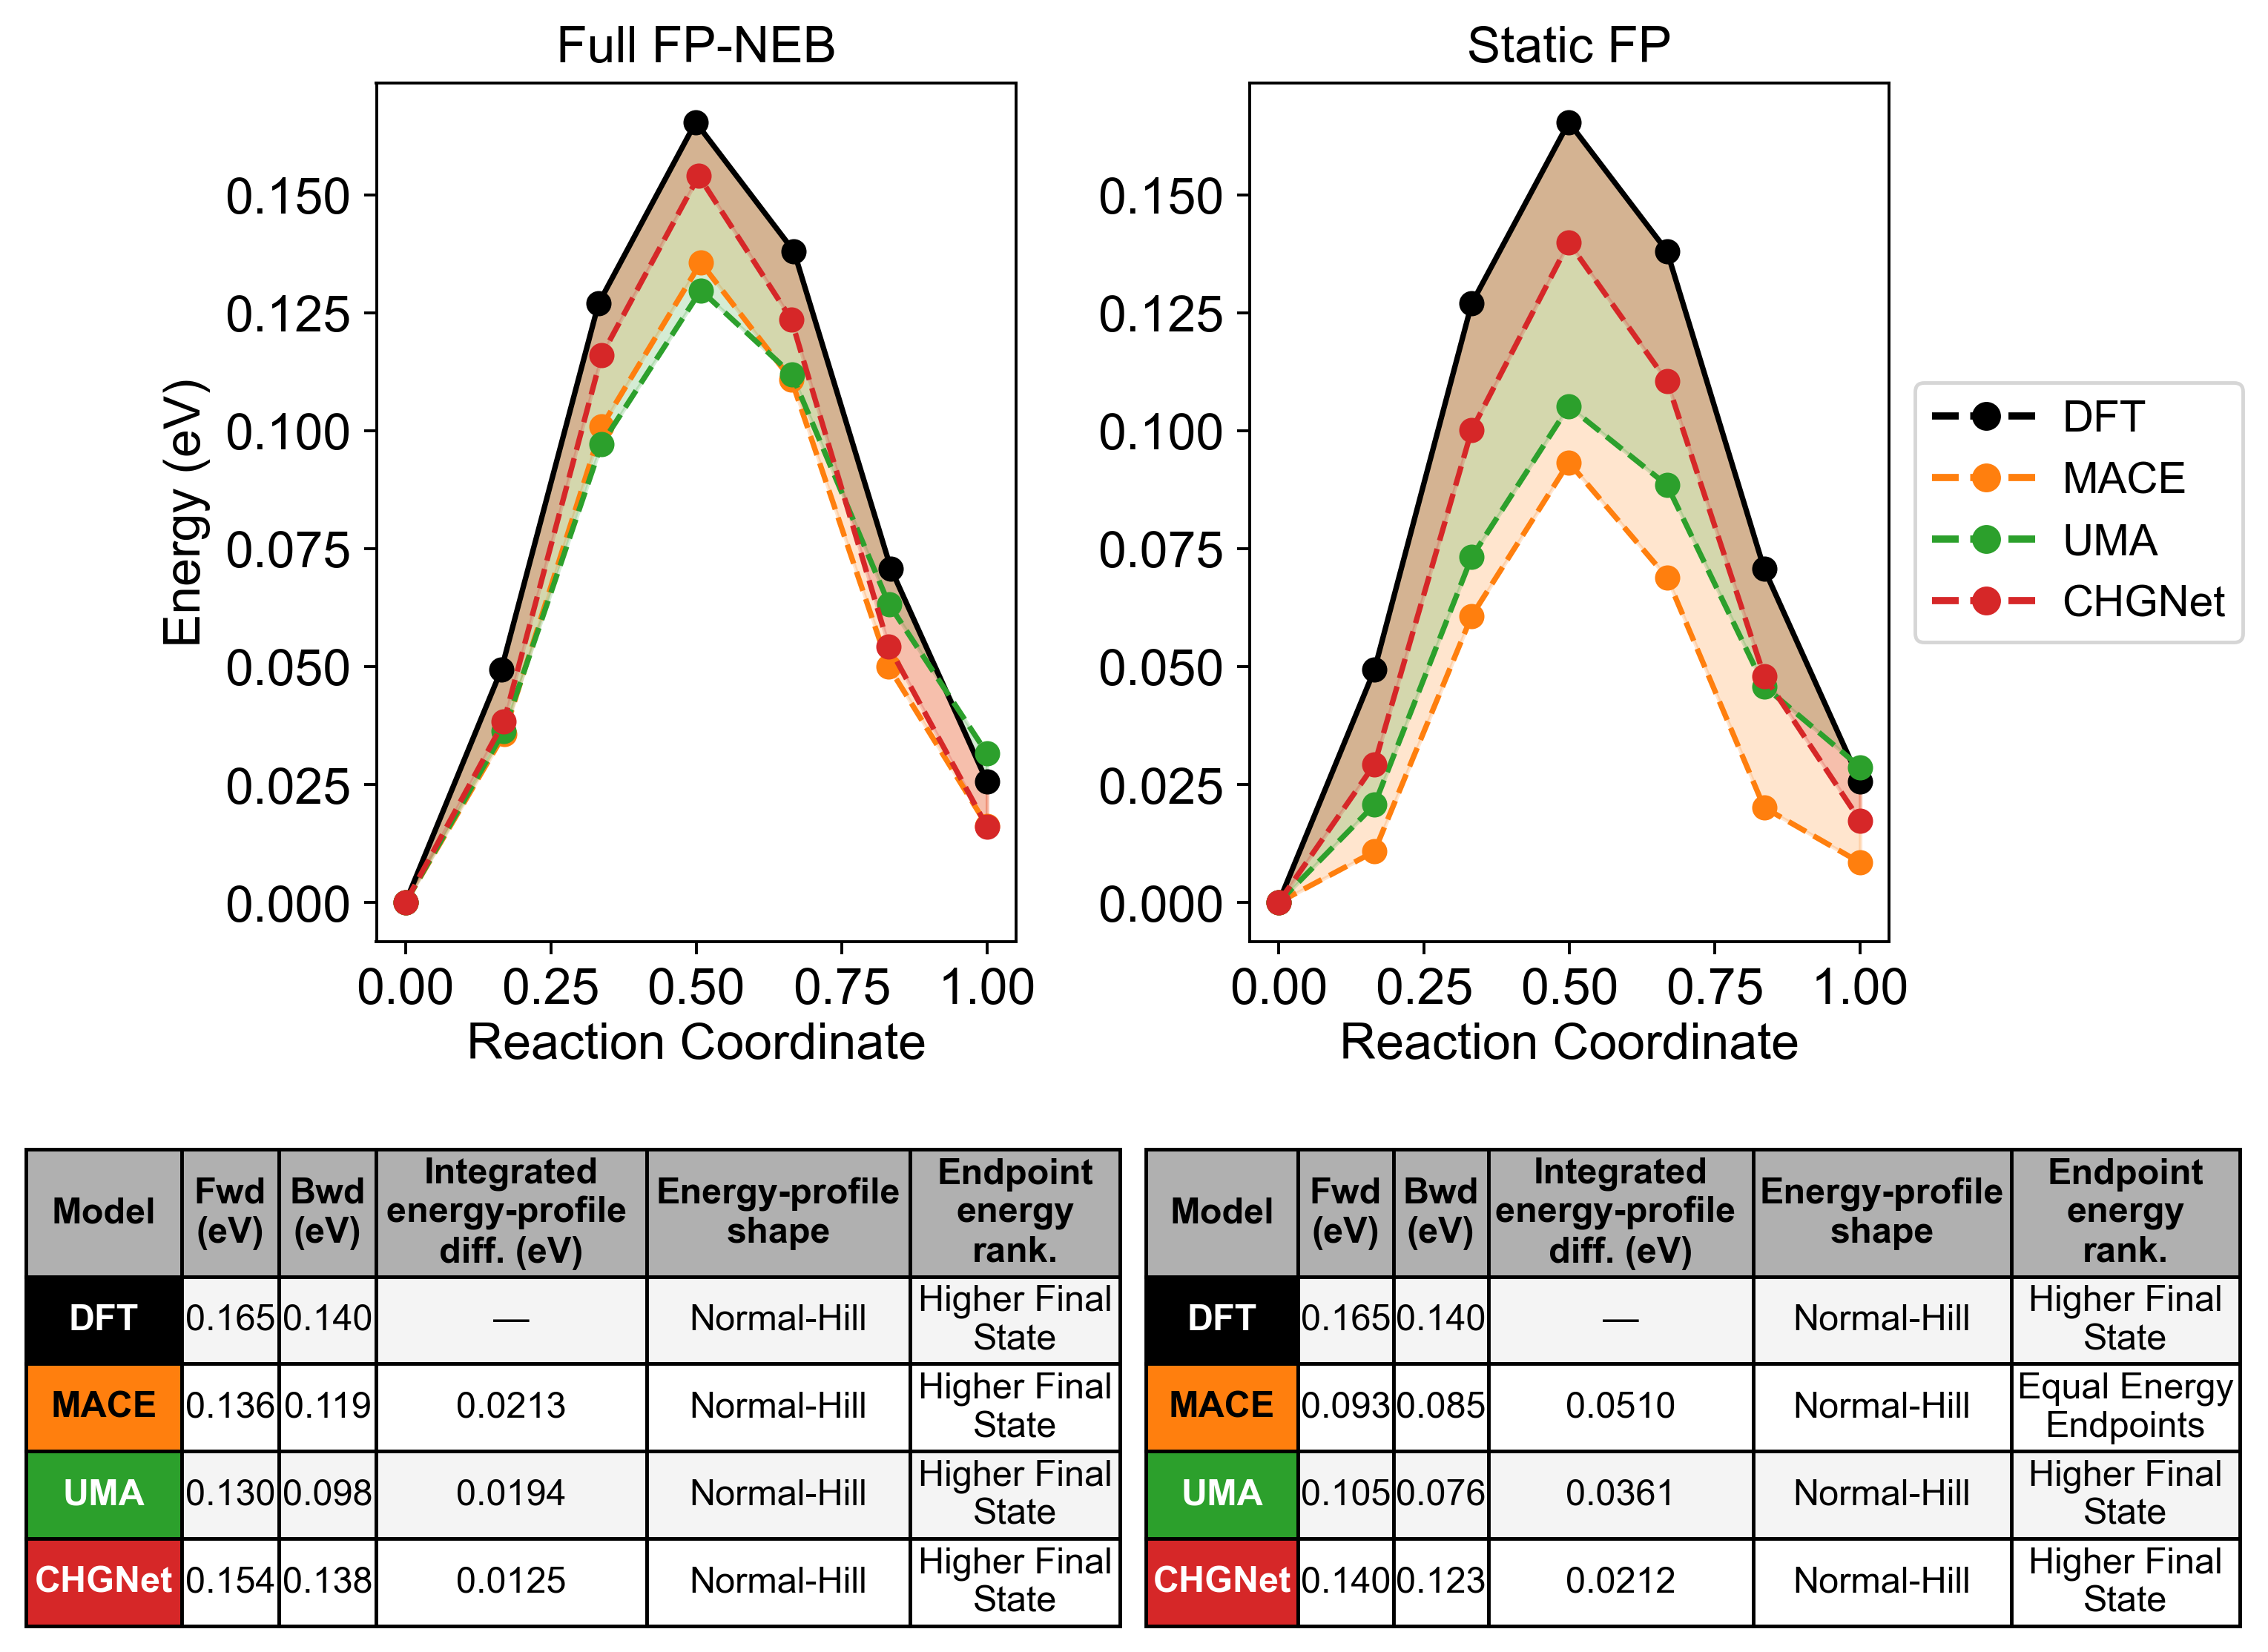

Saved: figures/Li$_{3}$YCl$_{6}$_29966_path8_NEB.svg


In [21]:
plot_case_study_neb_path(
    target_icsd="29966",
    target_path="8",
    fig_h_in = 6.5,
    df_dft_valid=dft_valid_path_metrics_df,
    df_classification_common=fp_path_metrics_by_short_mode,
    full_curve_label = "Full FP-NEB",
    static_curve_label = "Static FP",
    static_table_title=None,
    full_table_title= None,
    show_ylabel="left",
    dft_index_lookup=dft_image_position_by_path,
    df_ICSD=material_metadata_df,
    neb_paths_dft=dft_neb_images_by_position,
    neb_structures_all_mlip=neb_images_position_by_protocol,
    mlip_index_lookup=fp_image_position_by_fp_protocol_path,
    df_classification=fp_path_metrics_by_short_mode,
    df_classification_DFT=dft_path_metrics_df,
    figures_dir=FIGURES_DIR,
    outlier_threshold=OUTLIER_THRESHOLD,
)

## 7. Summary of key NEB metrics

This summary covers, for every FP: non-converged full FP-NEB paths,
barrier error (full and static protocols), endpoint energy-ranking
agreement, endpoint energy-difference error, and energy-profile shape
agreement, following the wording of manuscript Table 8. Per-path forward
and backward barriers are used internally to calculate the combined
barrier-error value shown here; separate forward/backward MAE/RMSE,
outlier-threshold-restricted errors, energy-range MAE/RMSE, and mean
endpoint RMSD are not part of this compact summary (endpoint RMSD is
reported in its own section below).


In [22]:
key_neb_metrics_summary_df = compute_key_neb_metrics_summary(
    dft_valid_path_metrics_df, fp_path_metrics_by_protocol, dft_path_metrics_df,
    full_fp_neb_status_by_fp_path, endpoint_rmsd_by_fp_protocol_path, benchmark_pathways_df,
    dft_neb_images_by_path, full_fp_neb_images_by_fp_path, fp_static_on_dft_neb_images_by_fp_path,
    FP_ORDER, OUTLIER_THRESHOLD, area_between_curves, simplify_class,
)
print(f"key_neb_metrics_summary_df: {len(key_neb_metrics_summary_df)} FPs")


key_neb_metrics_summary_df: 7 FPs


,Non-conv. paths (n/total),Barrier error (eV) (full),Barrier error (eV) (static),Endpoint energy-diff. error (eV) (full),Endpoint energy rank. agr. (%) (full),Energy-profile shape agr. (%) (full)
MACE-MP0_medium,1/154,0.0650 / 0.1204,0.0700 / 0.1300,0.0275 / 0.0606,85.6209,92.8105
CHGNET,2/154,0.1150 / 0.1557,0.1150 / 0.1503,0.0358 / 0.0690,78.2895,93.4211
M3GNET_pes,1/154,0.1550 / 0.2155,0.1600 / 0.2251,0.0439 / 0.0797,77.1242,93.4641
UMA_s1_p1,3/154,0.0500 / 0.0906,0.0600 / 0.1005,0.0258 / 0.0627,88.0795,95.3642
M3GNET_matpes_PBE,1/154,0.1750 / 0.2402,0.1800 / 0.2451,0.0412 / 0.0758,73.2026,89.5425
TensorNET_matpes_PBE,0/154,0.1000 / 0.1551,0.1100 / 0.1651,0.0386 / 0.0819,80.5195,90.2597
MACE_matpes_pbe,4/154,0.1100 / 0.1503,0.1150 / 0.1603,0.0329 / 0.0699,79.3333,93.3333


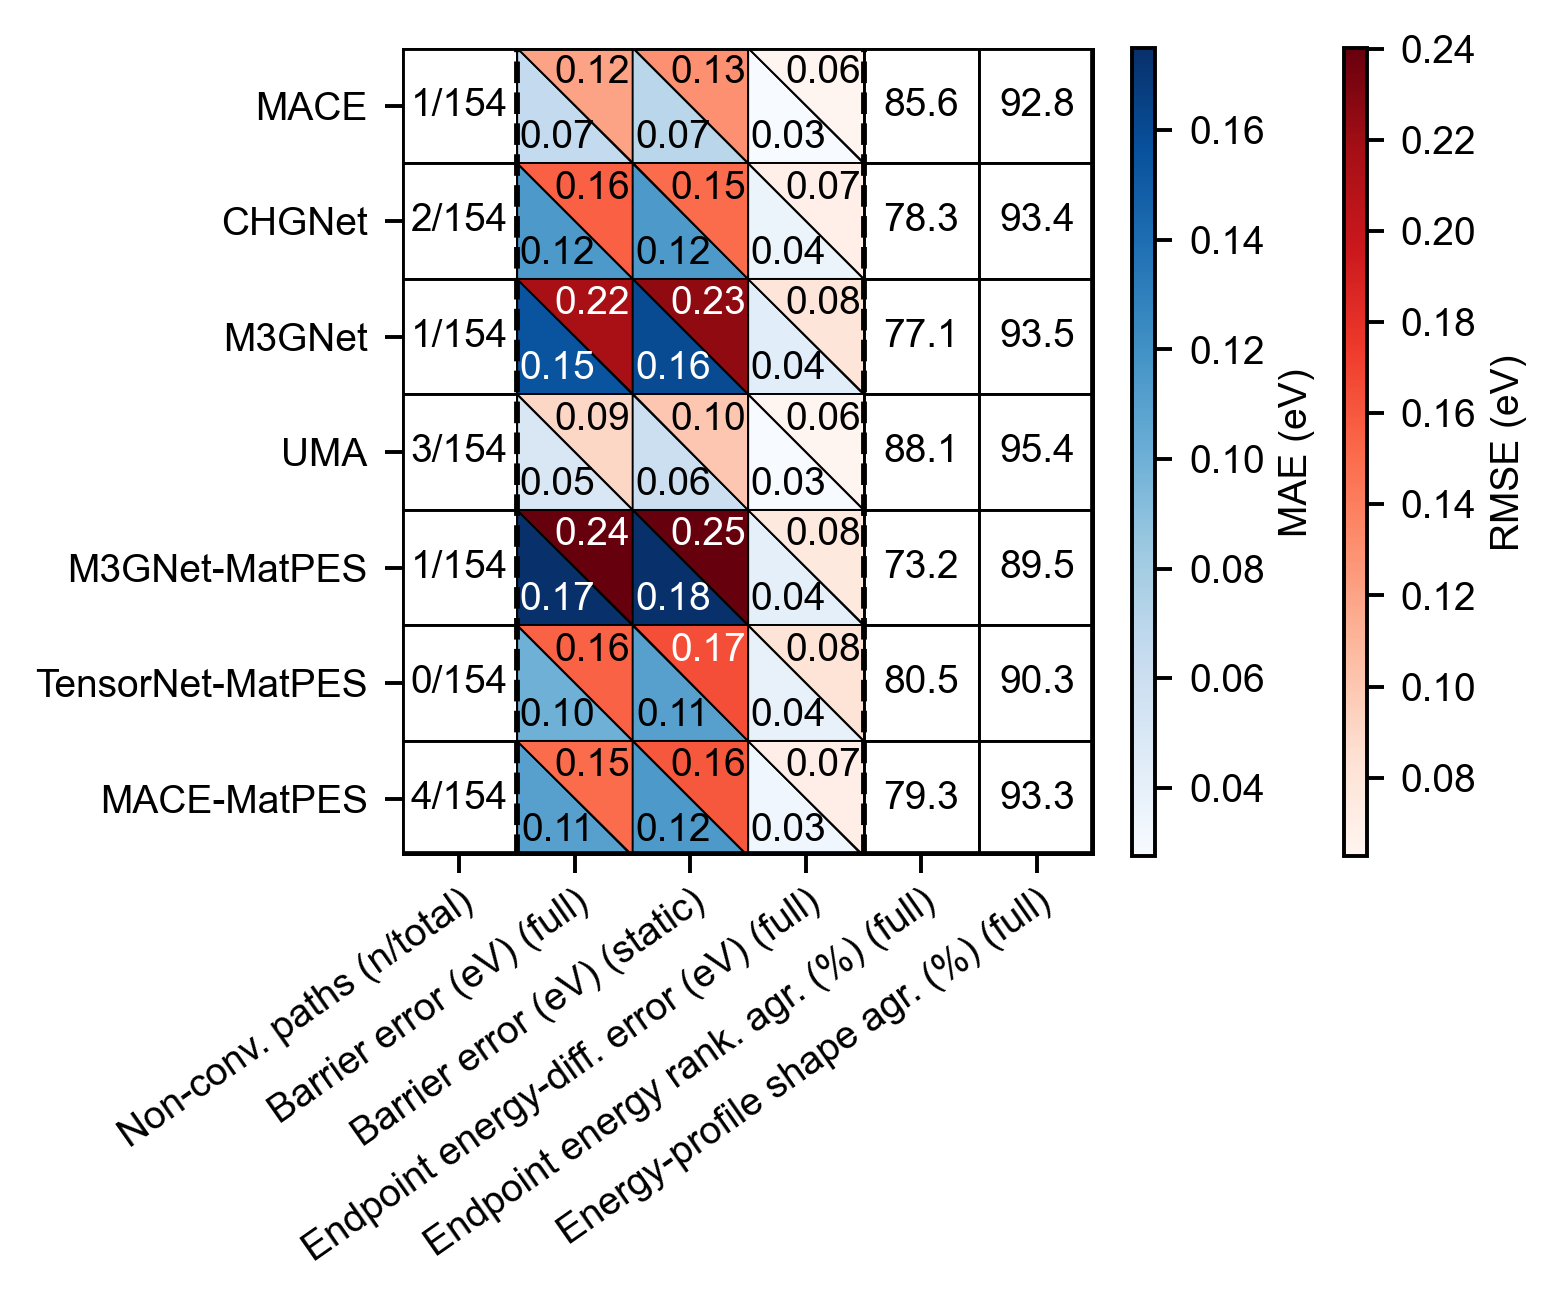

In [23]:
display(key_neb_metrics_summary_df)

CBAR_W, CBAR_GAP, TEXT_SIZE = 0.006, 0.05, 6.5
rect_pre_cols = ["Non-conv. paths (n/total)"]
tri_cols = ["Barrier error (eV) (full)", "Barrier error (eV) (static)",
            "Endpoint energy-diff. error (eV) (full)"]
rect_cols = ["Endpoint energy rank. agr. (%) (full)", "Energy-profile shape agr. (%) (full)"]

plot_3col_triangular(
    key_neb_metrics_summary_df[tri_cols], title=None, text_size=8, figsize=(1.8 * 6, 3.0), dpi=350,
    cbar_w=CBAR_W, cbar_gap=CBAR_GAP, cbar_mae_labelpad=3, cbar_rmse_labelpad=3, cbar_offset=0.01,
    col_labels=rect_pre_cols + tri_cols + rect_cols,
    rect_cols_pre=[key_neb_metrics_summary_df[c].tolist() for c in rect_pre_cols],
    rect_cols=[key_neb_metrics_summary_df[c].values for c in rect_cols],
    tick_rotation=LABEL_ROTATION, save_path=str(FIGURES_DIR / "figure8_full_fp_neb_summary.svg"),
)


## 8. Endpoint-structure relaxation error

Endpoint RMSD (`compute_endpoint_rmsd`, StructureMatcher ltol=0.5,
stol=0.5, angle_tol=10.0, unchanged) compares the full-mode FP-relaxed
endpoints against the DFT-NEB reference endpoints, restricted to
NEB-converged paths. The static protocol is excluded: its endpoints are
the DFT geometries themselves, so RMSD is trivially near zero. This
analysis corresponds to Table 9 in the manuscript.

### Generate the endpoint RMSD table


In [24]:
def _rmsd_summary_table(ep_key, label):
    rows = []
    for fp_key in FP_ORDER:
        md_ = endpoint_rmsd_by_fp_protocol_path.get(fp_key, {}).get(PROTOCOL_FULL_FP_NEB, {})
        if not md_:
            continue
        conv_lookup = full_fp_neb_status_by_fp_path.get(fp_key, {})
        n_total = len(md_)
        n_conv = sum(1 for pkey in md_
                     if conv_lookup.get(tuple(pkey.split("|")), {}).get("neb_converged", True))
        vals = [v[ep_key] for pkey, v in md_.items()
                if ep_key in v and not np.isnan(v[ep_key])
                and conv_lookup.get(tuple(pkey.split("|")), {}).get("neb_converged", True)]
        n_mapped = len(vals)
        if not vals:
            rows.append({"FP": fp_key, "n_conv": n_conv, "n_total": n_total,
                         "Avg RMSD (Å)": np.nan, "Max RMSD (Å)": np.nan, "Map Success (%)": 0.0,
                         "RMSD < 0.05 Å (%)": np.nan, "RMSD < 0.10 Å (%)": np.nan, "RMSD < 0.20 Å (%)": np.nan})
            continue
        a = np.array(vals)
        rows.append({
            "FP": fp_key, "n_conv": n_conv, "n_total": n_total,
            "Avg RMSD (Å)": round(float(a.mean()), 4), "Max RMSD (Å)": round(float(a.max()), 4),
            "Map Success (%)": round(100 * n_mapped / n_conv, 1) if n_conv else 0.0,
            "RMSD < 0.05 Å (%)": round(100 * (a < 0.05).sum() / n_mapped, 1),
            "RMSD < 0.10 Å (%)": round(100 * (a < 0.10).sum() / n_mapped, 1),
            "RMSD < 0.20 Å (%)": round(100 * (a < 0.20).sum() / n_mapped, 1),
        })
    df = pd.DataFrame(rows).set_index("FP")
    print(f"\n-- {label} --")
    display(df)

# Compact mapping-validation line, then the single combined Table 9 output
# (per-image-0 / per-image-N breakdowns are available via _rmsd_summary_table
# above if needed; not displayed separately here).
print("Endpoint RMSD [full mode, NEB-converged paths only, both endpoints combined]")
comb_rows = []
for fp_key in FP_ORDER:
    md_ = endpoint_rmsd_by_fp_protocol_path.get(fp_key, {}).get(PROTOCOL_FULL_FP_NEB, {})
    if not md_:
        continue
    conv_lookup = full_fp_neb_status_by_fp_path.get(fp_key, {})
    n_conv = sum(1 for pkey in md_ if conv_lookup.get(tuple(pkey.split("|")), {}).get("neb_converged", True))
    vals = []
    for pkey, v in md_.items():
        if not conv_lookup.get(tuple(pkey.split("|")), {}).get("neb_converged", True):
            continue
        for ep in ["rmsd_img0", "rmsd_img_last"]:
            val = v.get(ep, float("nan"))
            if not np.isnan(val):
                vals.append(val)
    n_total_ep, n_mapped_ep = 2 * n_conv, len(vals)
    if not vals:
        comb_rows.append({"FP": fp_key, "n_conv": n_conv, "n_total": len(md_),
                          "Endpoint map success (%)": 0.0, "Avg RMSD (Å)": np.nan, "Max RMSD (Å)": np.nan,
                          "RMSD < 0.05 Å (%)": np.nan, "RMSD < 0.10 Å (%)": np.nan, "RMSD < 0.20 Å (%)": np.nan})
        continue
    a = np.array(vals)
    comb_rows.append({
        "FP": fp_key, "n_conv": n_conv, "n_total": len(md_),
        "Endpoint map success (%)": round(100 * n_mapped_ep / n_total_ep, 1),
        "Avg RMSD (Å)": round(float(a.mean()), 2), "Max RMSD (Å)": round(float(a.max()), 2),
        "RMSD < 0.05 Å (%)": round(100 * (a < 0.05).sum() / n_mapped_ep, 1),
        "RMSD < 0.10 Å (%)": round(100 * (a < 0.10).sum() / n_mapped_ep, 1),
        "RMSD < 0.20 Å (%)": round(100 * (a < 0.20).sum() / n_mapped_ep, 1),
    })
table9_endpoint_rmsd = pd.DataFrame(comb_rows).set_index("FP")
display(table9_endpoint_rmsd)


Endpoint RMSD [full mode, NEB-converged paths only, both endpoints combined]


,n_conv,n_total,Endpoint map success (%),Avg RMSD (Å),Max RMSD (Å),RMSD < 0.05 Å (%),RMSD < 0.10 Å (%),RMSD < 0.20 Å (%)
FP,,,,,,,,
MACE-MP0_medium,153,154,100.0000,0.0600,0.7300,72.5000,86.6000,94.1000
CHGNET,152,154,100.0000,0.0800,0.6600,54.6000,78.3000,91.4000
M3GNET_pes,153,154,100.0000,0.1300,0.6600,37.9000,61.4000,78.1000
UMA_s1_p1,151,154,100.0000,0.0500,0.6200,76.8000,87.4000,96.7000
M3GNET_matpes_PBE,153,154,99.7000,0.1600,0.8300,27.9000,50.5000,73.8000
TensorNET_matpes_PBE,154,154,100.0000,0.0800,0.9600,53.9000,79.2000,94.2000
MACE_matpes_pbe,150,154,100.0000,0.0600,0.8300,68.0000,85.7000,94.7000


## 9. Force errors on the FP-NEB path

### Representative along-path force-error plot

This produces the along-path force-error comparison reported as Figure 9
in the manuscript.


  [UMA_s1_p1 | ICSD=113152 path=1]  dft_idx=1  full_idx=44  static_idx=44  barriers=['full', 'static']
  [UMA_s1_p1 | ICSD=255942 path=14]  dft_idx=59  full_idx=11  static_idx=11  barriers=['full', 'static']


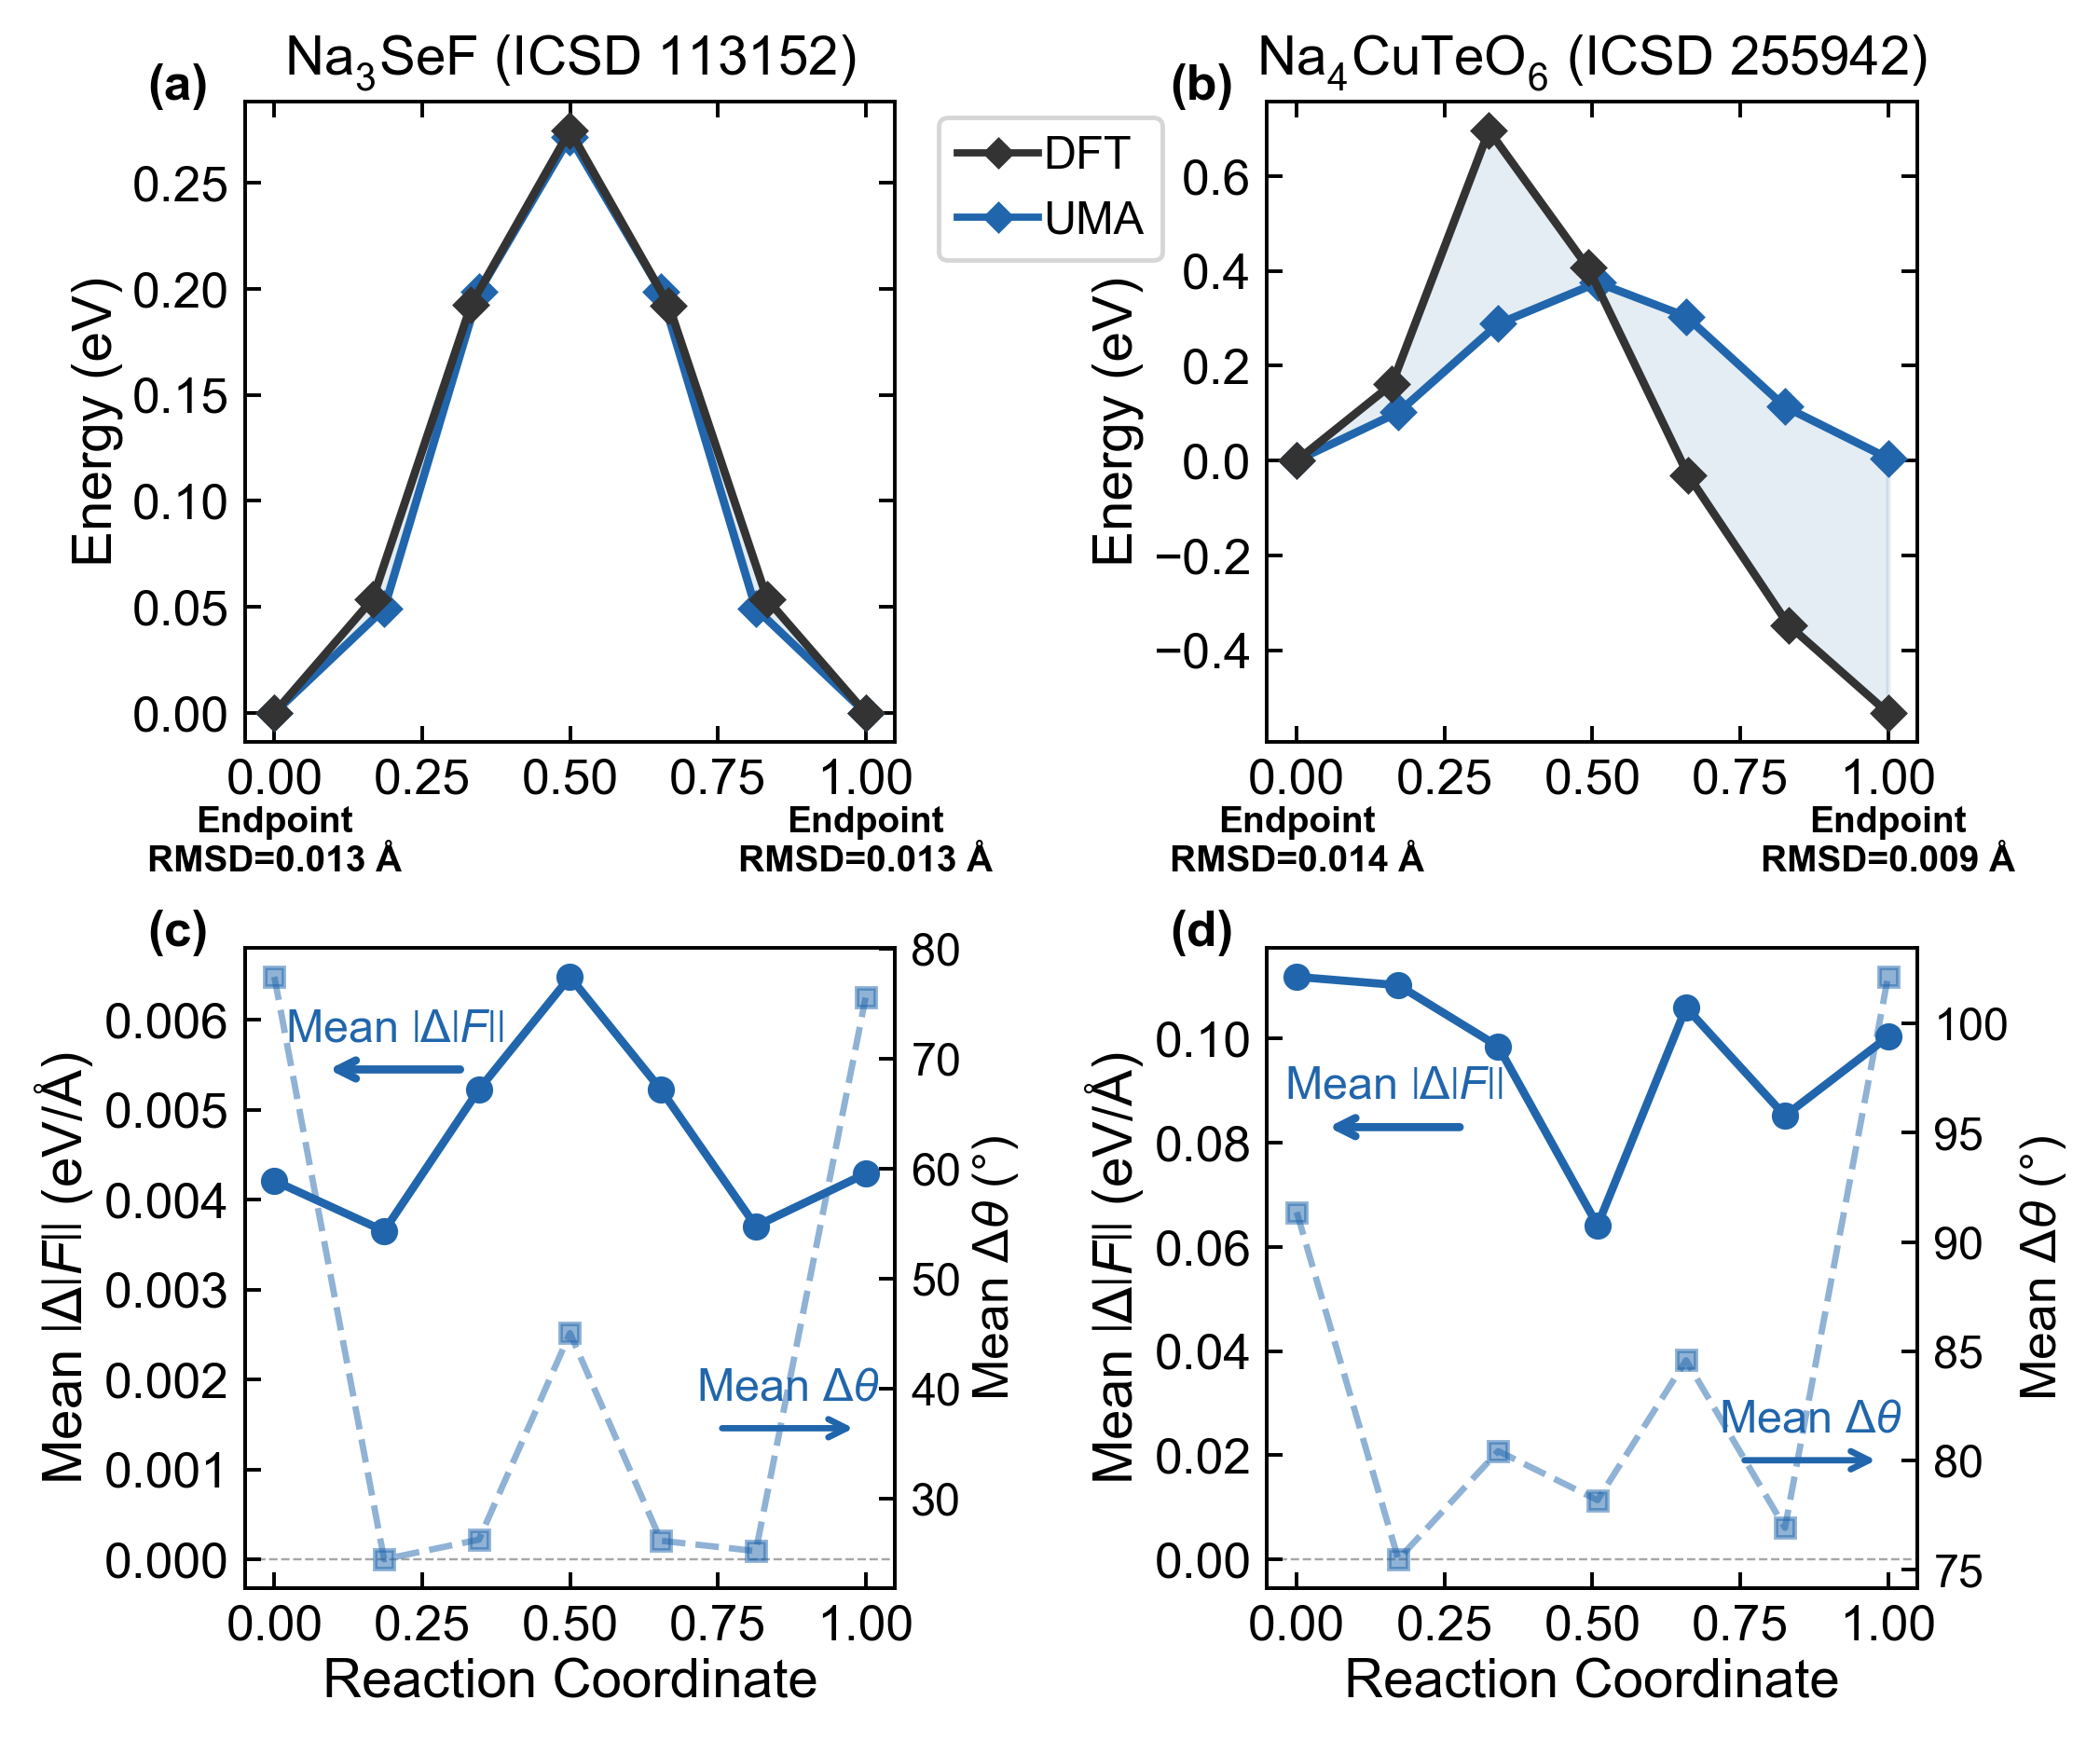

(<Figure size 2275x2100 with 6 Axes>,
 array([[<Axes: title={'center': 'Na$_{3}$SeF (ICSD 113152)'}, ylabel='Energy (eV)'>,
         <Axes: title={'center': 'Na$_{4}$CuTeO$_{6}$ (ICSD 255942)'}, ylabel='Energy (eV)'>],
        [<Axes: xlabel='Reaction Coordinate', ylabel='Mean $\\left|\\Delta\\left|F\\right|\\right|$ (eV/Å)'>,
         <Axes: xlabel='Reaction Coordinate', ylabel='Mean $\\left|\\Delta\\left|F\\right|\\right|$ (eV/Å)'>]],
       dtype=object))

In [25]:
plot_two_path_force_error_full(
    sel_mlip="UMA_s1_p1",
    selected_paths=[('113152', '1'), ('255942', '14')],
    model_names=FP_DISPLAY_NAMES,
    df_ICSD=material_metadata_df,
    df_dft_valid=dft_valid_path_metrics_df,
    df_classification_common=fp_path_metrics_by_short_mode,
    dft_index_lookup=dft_image_position_by_path,
    mlip_index_lookup=fp_image_position_by_fp_protocol_path,
    neb_paths_dft=dft_neb_images_by_position,
    neb_structures_all_mlip=neb_images_position_by_protocol,
    endpoint_rmsd_data=endpoint_rmsd_by_short_mode,
    full_fp_neb_path_force_errors=full_fp_neb_path_force_errors_df,
)

### Force-error statistics grouped by endpoint RMSD and barrier error

> SI Table 4. Force errors on the FP-NEB path. Converged paths are
> grouped by endpoint-structure RMSD and barrier error. For each image,
> the force error is averaged over all atoms; reported values are the
> mean and maximum across all images in each group.


In [26]:
case_status_by_case, case_force_errors_by_case = build_threshold_case_membership(
    CASE_THRESHOLDS, full_fp_neb_path_force_errors_df, endpoint_rmsd_by_fp_protocol_path,
    dft_valid_path_metrics_df, fp_path_metrics_by_protocol, full_fp_neb_status_by_fp_path, FP_ORDER,
)

# Coverage counts shown separately (not inside the manuscript table's column
# headers, per spec) -- generated from CASE_THRESHOLDS itself so the label
# text always accurately reflects the actual predicate being computed.
def _case_predicate_text(spec):
    rmsd_word = "Both" if spec["rmsd_mode"] == "both" else "Either"
    barrier_word = "both" if spec["barrier_mode"] == "both" else "either"
    return (f"{rmsd_word} endpoint RMSD {spec['rmsd_op']} {spec['rmsd_val']} Å; "
            f"{barrier_word} Fwd/Bwd barrier error {spec['barrier_op']} {spec['barrier_val']} eV")

cases = list(CASE_THRESHOLDS.keys())
print("Coverage (pathway-FP combinations per group):")
for c in cases:
    n_fps = case_status_by_case[c]["fp_key"].nunique() if not case_status_by_case[c].empty else 0
    print(f"  {CASE_LABELS[c]}: {n_fps} FPs, {len(case_status_by_case[c])} paths -- {_case_predicate_text(CASE_THRESHOLDS[c])}")

col_labels = [_case_predicate_text(CASE_THRESHOLDS[c]) for c in cases]
row_labels = [
    "Mean/max |Δ|F|| over all images (eV/Å)",
    "Mean/max Δθ over all images (°)",
]
row_metrics = ["mean_abs_delta_force_magnitude", "mean_force_angle_error_deg"]
row_decimals = [3, 2]

data = {}
for label, metric, dec in zip(row_labels, row_metrics, row_decimals):
    data[label] = [
        (f"{case_force_errors_by_case[c][metric].mean():.{dec}f} / "
         f"{case_force_errors_by_case[c][metric].max():.{dec}f}")
        if not case_force_errors_by_case[c].empty else "-"
        for c in cases
    ]
si_table_4 = pd.DataFrame(data, index=col_labels).T
display(si_table_4)


Coverage (pathway-FP combinations per group):
  good rmsd, bad barrier: 7 FPs, 45 paths -- Both endpoint RMSD < 0.05 Å; either Fwd/Bwd barrier error > 0.1 eV
  good rmsd, good barrier: 5 FPs, 22 paths -- Both endpoint RMSD < 0.05 Å; both Fwd/Bwd barrier error < 0.01 eV
  bad rmsd, good barrier: 1 FPs, 1 paths -- Either endpoint RMSD > 0.2 Å; both Fwd/Bwd barrier error < 0.01 eV
  bad rmsd, bad barrier: 7 FPs, 36 paths -- Either endpoint RMSD > 0.2 Å; either Fwd/Bwd barrier error > 0.1 eV


,Both endpoint RMSD < 0.05 Å; either Fwd/Bwd barrier error > 0.1 eV,Both endpoint RMSD < 0.05 Å; both Fwd/Bwd barrier error < 0.01 eV,Either endpoint RMSD > 0.2 Å; both Fwd/Bwd barrier error < 0.01 eV,Either endpoint RMSD > 0.2 Å; either Fwd/Bwd barrier error > 0.1 eV
Mean/max |Δ|F|| over all images (eV/Å),0.093 / 0.350,0.046 / 0.091,0.049 / 0.058,0.396 / 0.834
Mean/max Δθ over all images (°),80.97 / 109.28,76.81 / 105.54,84.38 / 96.32,86.85 / 115.37


## 10. Barrier and energy-profile diagnostics

### Static FP summary

This corresponds to the static FP summary provided in the Supporting
Information.


In [27]:
# Section 10 needs the full profile-summary and barrier-summary DataFrames
# (not just the compact key_neb_metrics_summary_df from Section 7) for its
# own full-vs-static diagnostics below. Same helper calls as Section 7's
# compute_key_neb_metrics_summary uses internally, computed again here since
# Section 10's parity/violin/integrated-profile cells need the full-width
# DataFrames directly, not the compact summary.
profile_summary_by_protocol, _ = compute_profile_summaries(
    fp_path_metrics_by_protocol, dft_path_metrics_df, dft_neb_images_by_path,
    full_fp_neb_images_by_fp_path, fp_static_on_dft_neb_images_by_fp_path,
    full_fp_neb_status_by_fp_path, FP_ORDER, area_between_curves, simplify_class,
)
full_fp_neb_profile_summary_df = profile_summary_by_protocol[PROTOCOL_FULL_FP_NEB]
fp_static_on_dft_neb_profile_summary_df = profile_summary_by_protocol[PROTOCOL_FP_STATIC_ON_DFT_NEB]

_, full_fp_neb_convergence_summary = compute_barrier_error_summaries(
    dft_valid_path_metrics_df, fp_path_metrics_by_protocol, full_fp_neb_status_by_fp_path,
    endpoint_rmsd_by_fp_protocol_path, benchmark_pathways_df, FP_ORDER, OUTLIER_THRESHOLD,
)
ENDPOINT_LABEL, TOPOLOGY_LABEL = "Endpoint energy rank. agr. (%)", "Energy-profile shape agr. (%)"


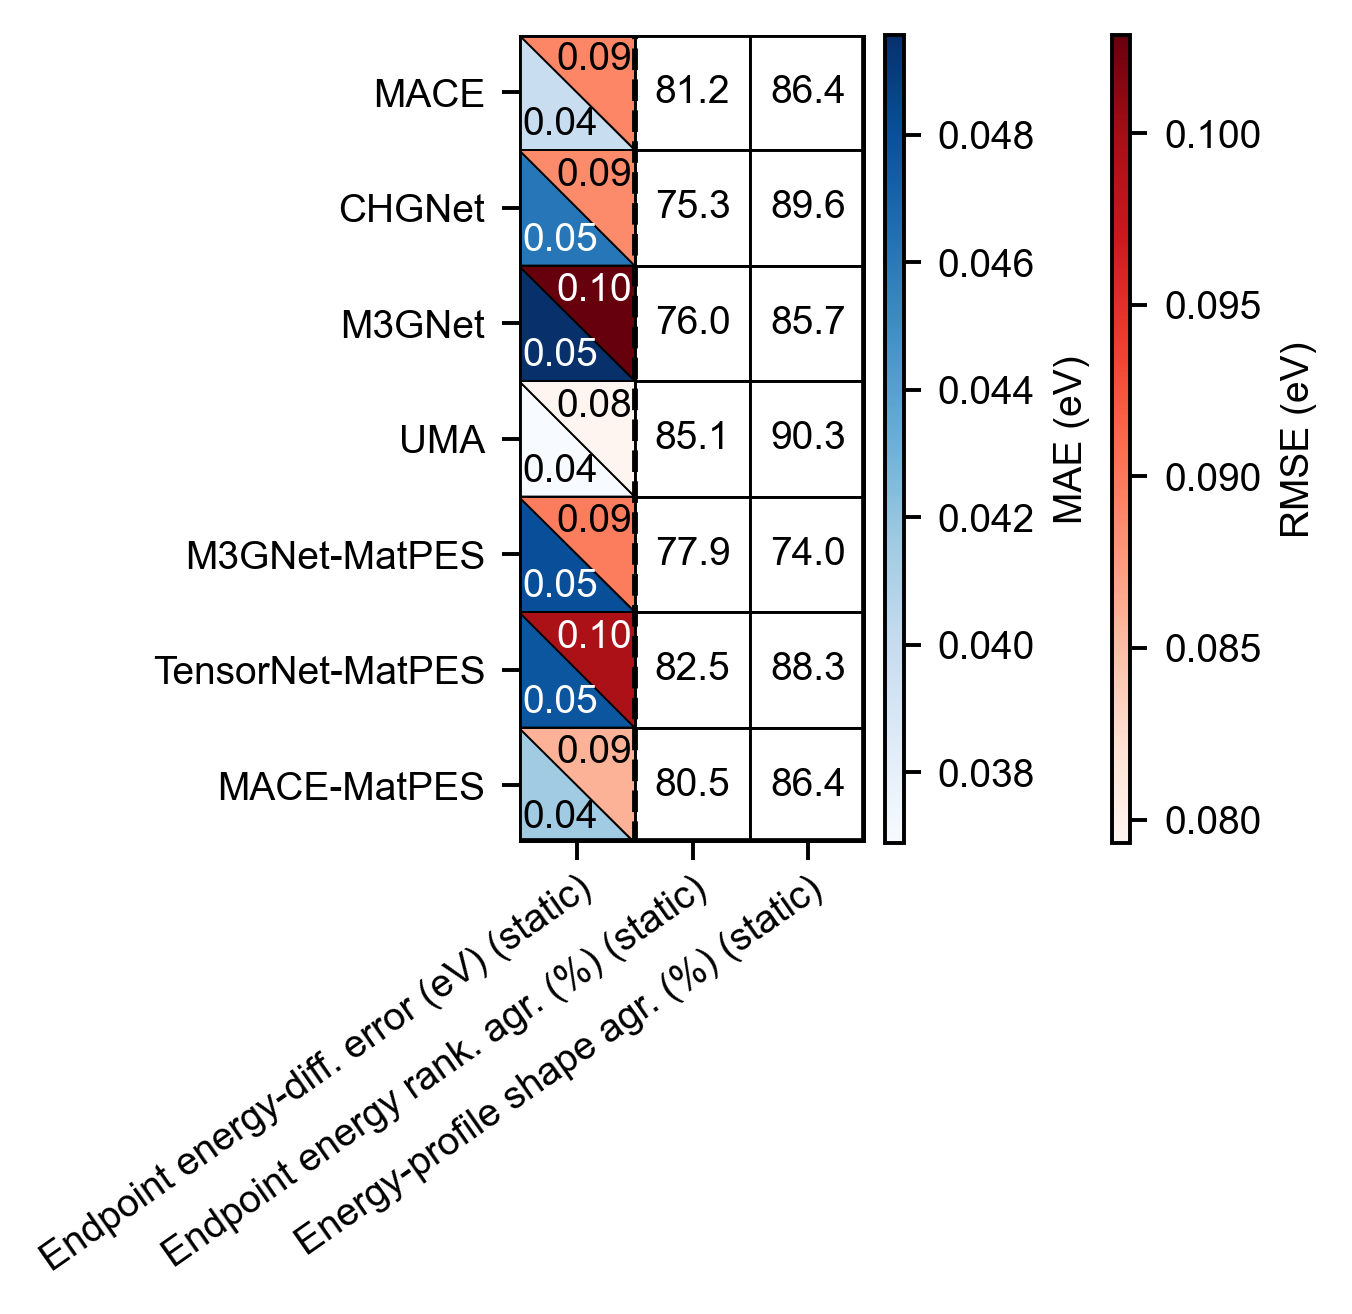

,Endpoint energy-diff. error (eV) (static),Endpoint energy rank. agr. (%) (static),Energy-profile shape agr. (%) (static)
FP,,,
MACE-MP0_medium,0.0399 / 0.0890,81.1688,86.3636
CHGNET,0.0461 / 0.0887,75.3247,89.6104
M3GNET_pes,0.0502 / 0.1044,75.9740,85.7143
UMA_s1_p1,0.0356 / 0.0765,85.0649,90.2597
M3GNET_matpes_PBE,0.0481 / 0.0897,77.9221,74.0260
TensorNET_matpes_PBE,0.0477 / 0.0993,82.4675,88.3117
MACE_matpes_pbe,0.0415 / 0.0859,80.5195,86.3636


In [28]:
df_results_indexed_static = fp_static_on_dft_neb_profile_summary_df.set_index("FP")
_static_index = df_results_indexed_static.index
topo_acc_comb_static = df_results_indexed_static["Pathway Topology Accuracy (%)"].reindex(_static_index)
rank_acc_comb_static = df_results_indexed_static["Endpoint Energy Ranking Accuracy (%)"].reindex(_static_index)
ep_dE_mae_tri_s = df_results_indexed_static["Endpoint ΔE MAE (eV)"].reindex(_static_index)
ep_dE_rmse_tri_s = df_results_indexed_static["Endpoint ΔE RMSE (eV)"].reindex(_static_index)
ep_dE_tri_static = (ep_dE_mae_tri_s.map(lambda x: f"{x:.4f}" if pd.notna(x) else "nan")
                     + " / " + ep_dE_rmse_tri_s.map(lambda x: f"{x:.4f}" if pd.notna(x) else "nan"))

tri_compact_s = {"Endpoint energy-diff. error (eV) (static)": ep_dE_tri_static}
rect_compact_s = {ENDPOINT_LABEL + " (static)": rank_acc_comb_static.values,
                   TOPOLOGY_LABEL + " (static)": topo_acc_comb_static.values}
df_compact_s = pd.DataFrame(tri_compact_s, index=_static_index)
plot_3col_triangular(
    df_compact_s, title="", text_size=8, figsize=(1.8 * 3, 3.0), dpi=350,
    cbar_w=0.01, cbar_gap=0.11, cbar_mae_labelpad=4, cbar_rmse_labelpad=4, cbar_offset=0.01,
    col_labels=list(tri_compact_s) + list(rect_compact_s),
    rect_cols_pre=None, rect_cols=list(rect_compact_s.values()),
    tick_rotation=LABEL_ROTATION, save_path=str(FIGURES_DIR / "section10_static_summary.svg"),
)
static_summary_table = pd.DataFrame({**tri_compact_s, **rect_compact_s}, index=_static_index)
display(static_summary_table)


### Barrier parity plots

Compares full FP-NEB and static FP barrier predictions against DFT; not a static-only analysis.


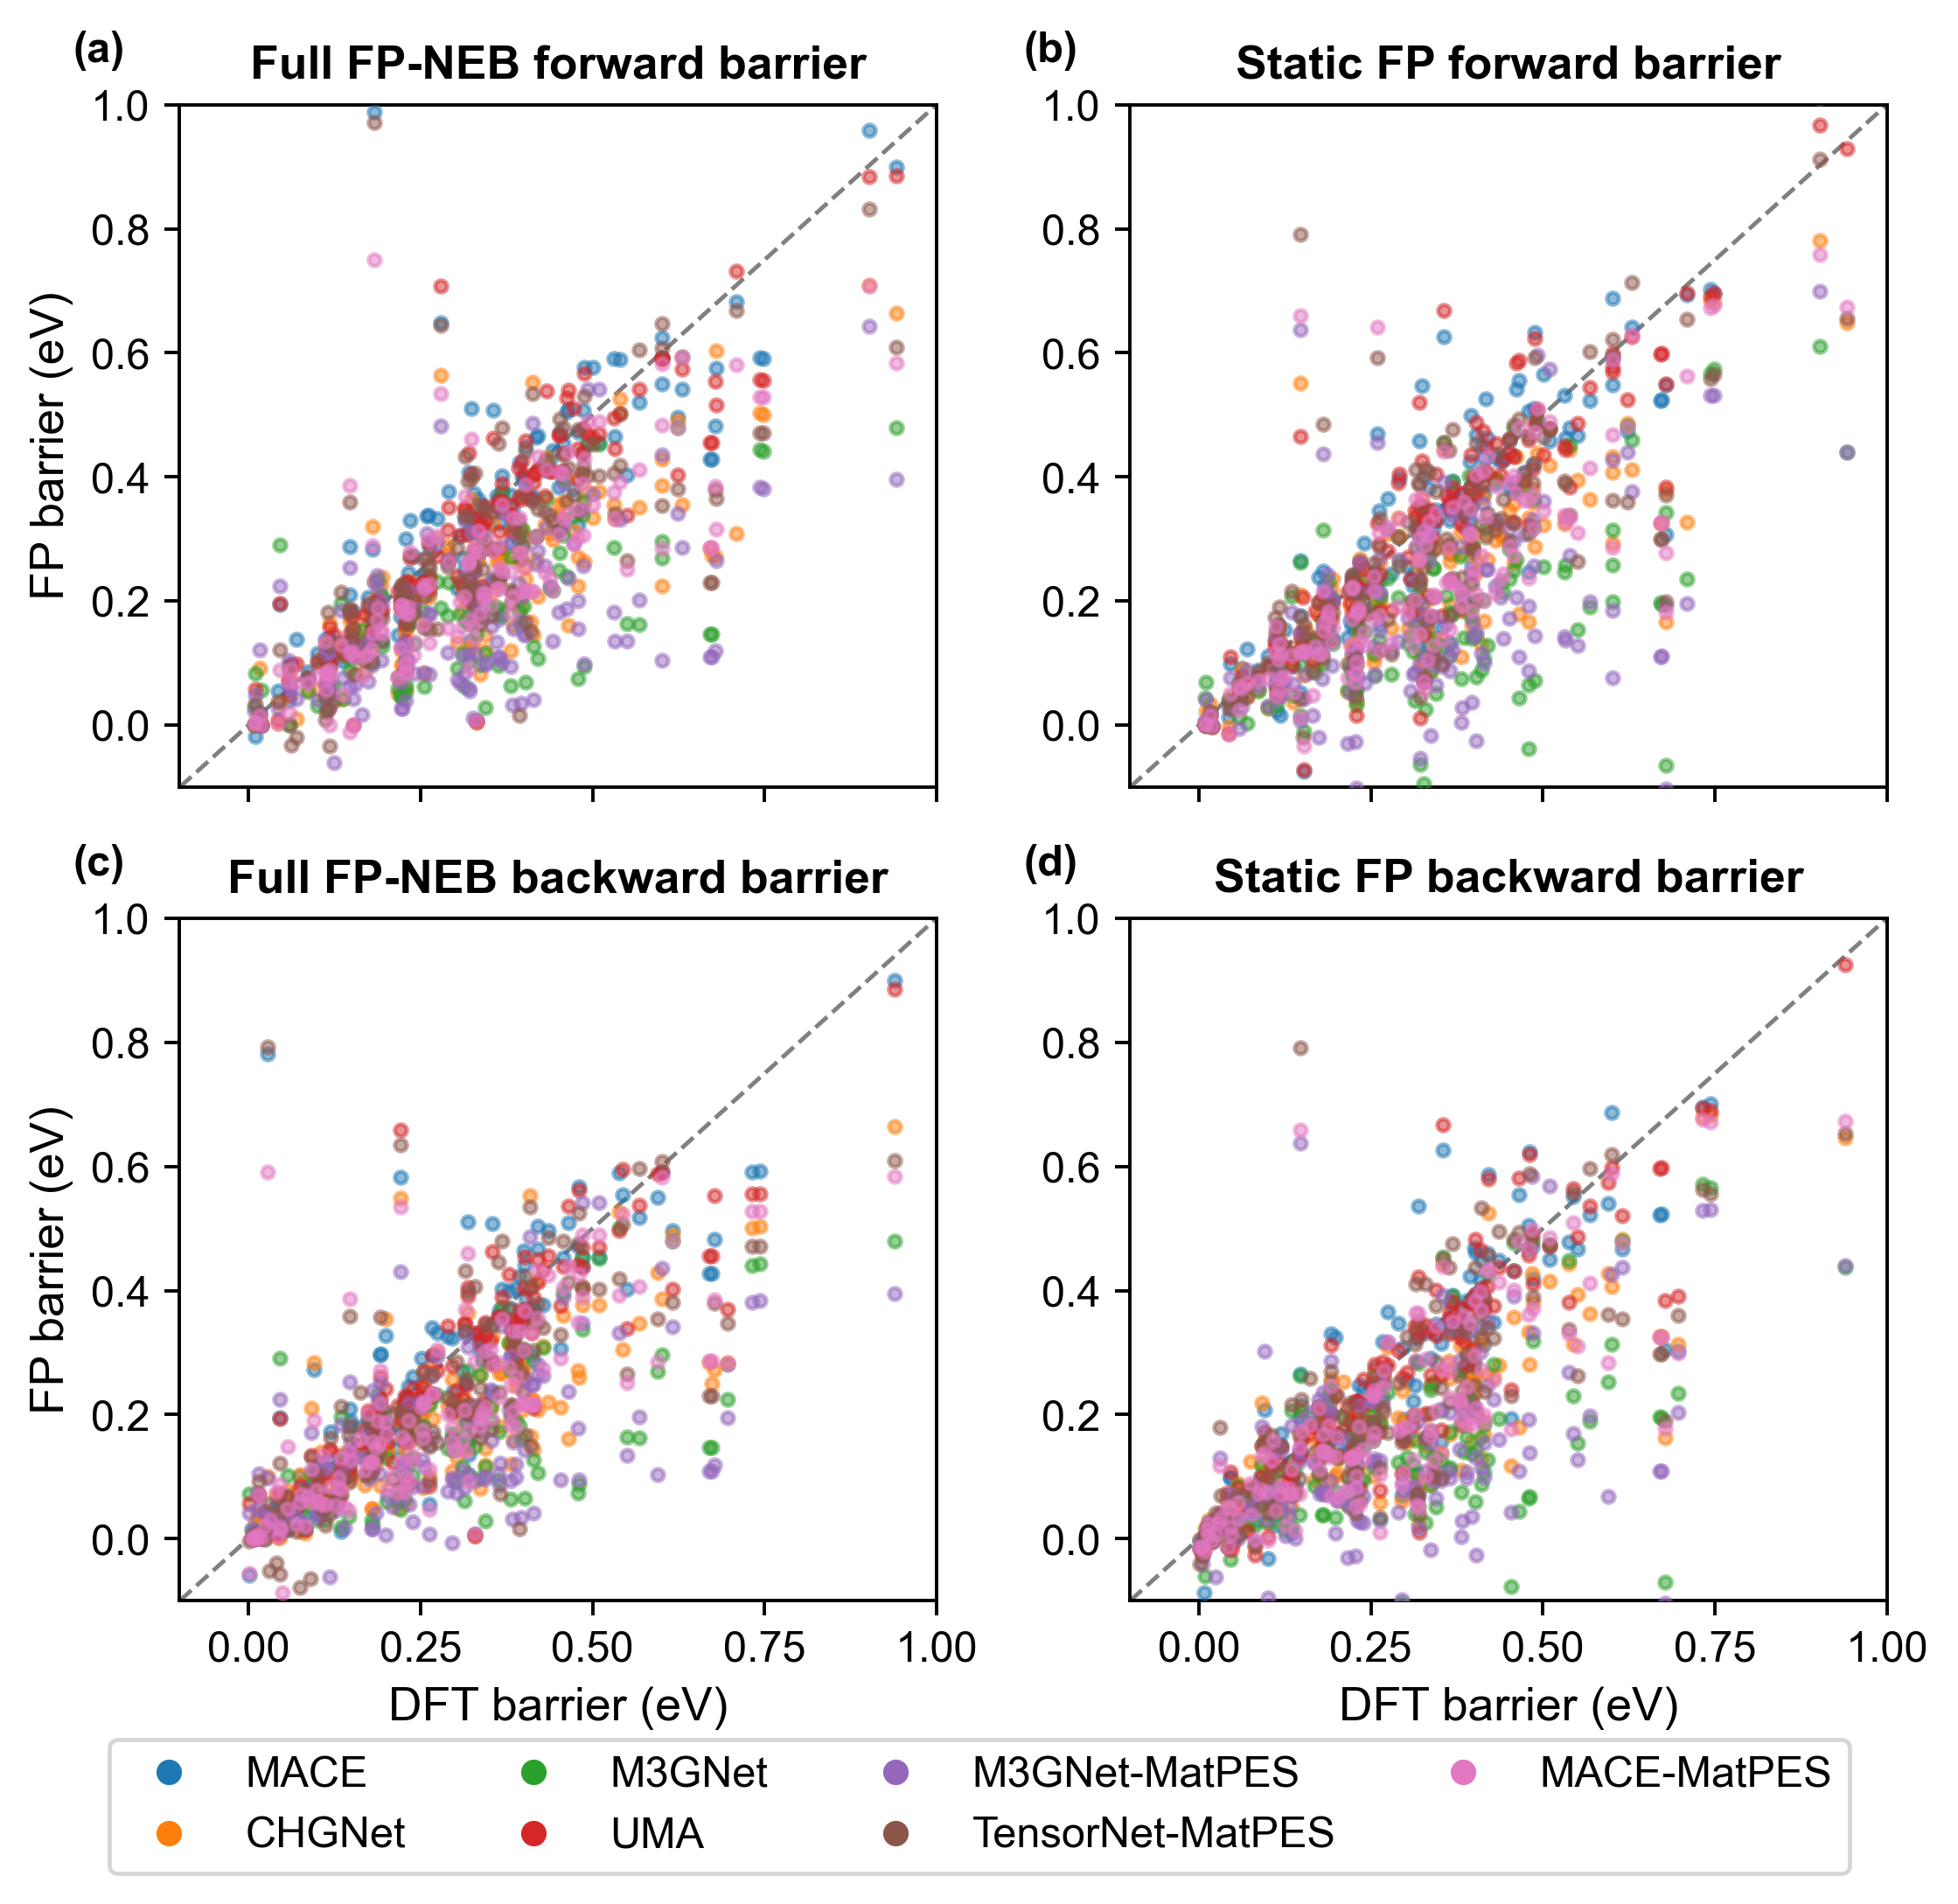

In [29]:
plot_parity_2x2(
    df_classification_common=fp_path_metrics_by_short_mode,
    df_dft_valid=dft_valid_path_metrics_df,
    mlip_order=FP_ORDER,
    conv_data={fp_key: {"full": full_fp_neb_status_by_fp_path.get(fp_key, {}), "static": {}} for fp_key in FP_ORDER},
    outlier_threshold=None,
    figsize=(6.5, 6), dpi=350, textsize=11, alpha=0.5, marker_size=8,
    xlim=(-0.1, 1.0), ylim=(-0.1, 1.0),
    panel_titles=["Full FP-NEB forward barrier", "Static FP forward barrier",
                  "Full FP-NEB backward barrier", "Static FP backward barrier"],
    panel_label_fontsize=10, panel_label_offset=(-25, 8),
    ylabel="FP barrier (eV)", xlabel="DFT barrier (eV)",
)

### Barrier-error distributions

Compares full FP-NEB forward, static FP forward, full FP-NEB backward, and static FP backward barrier errors; not a static-only diagnostic.


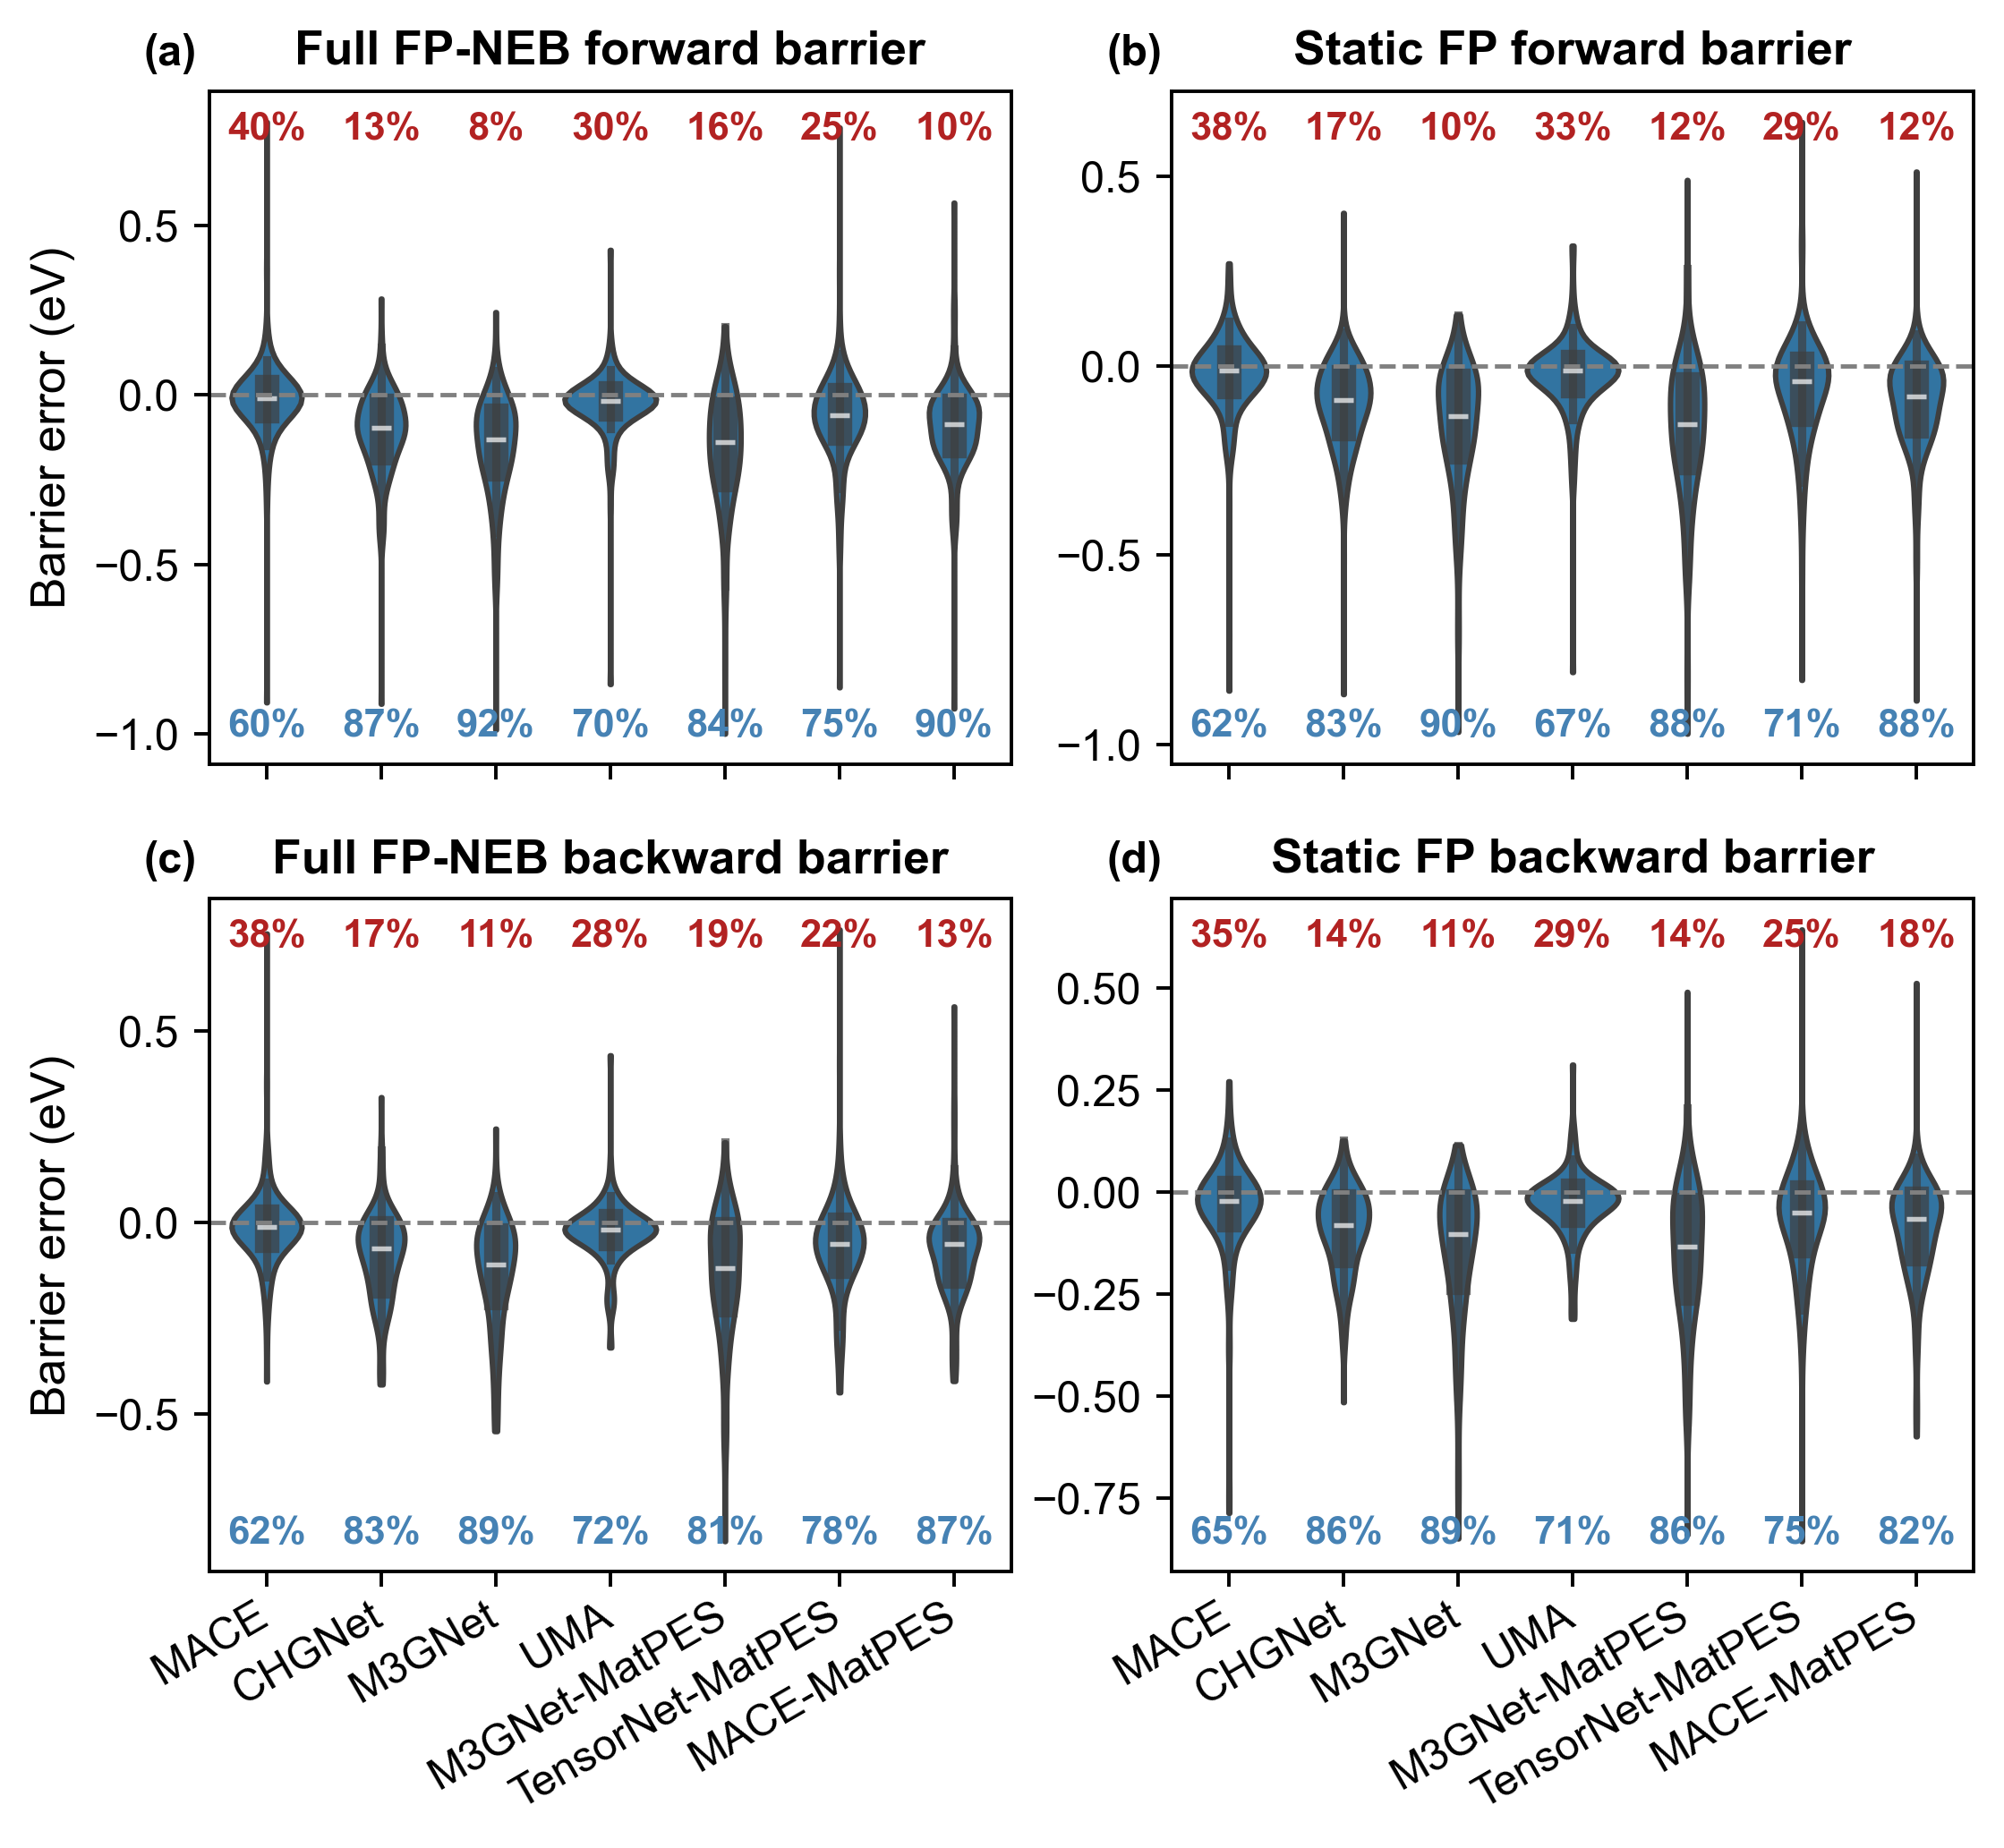

In [30]:
plot_violin_2x2(
    df_classification_common=fp_path_metrics_by_short_mode,
    df_classification_DFT_common=dft_path_metrics_df,
    mlip_order=FP_ORDER,
    conv_data={fp_key: {"full": full_fp_neb_status_by_fp_path.get(fp_key, {}), "static": {}} for fp_key in FP_ORDER},
    figsize=(6.5, 6), dpi=350, x_label_pad=2, box_alpha=0.7, x_label_shift=2, textsize=11,
    wspace=0.2, hspace=0.2,
    panel_titles=["Full FP-NEB forward barrier", "Static FP forward barrier",
                  "Full FP-NEB backward barrier", "Static FP backward barrier"],
    panel_label_fontsize=10, panel_label_offset=(-15, 4), xlabel=None,
)

### Integrated energy-profile differences

Continues to compare full and static protocols; integration and averaging implementation unchanged.


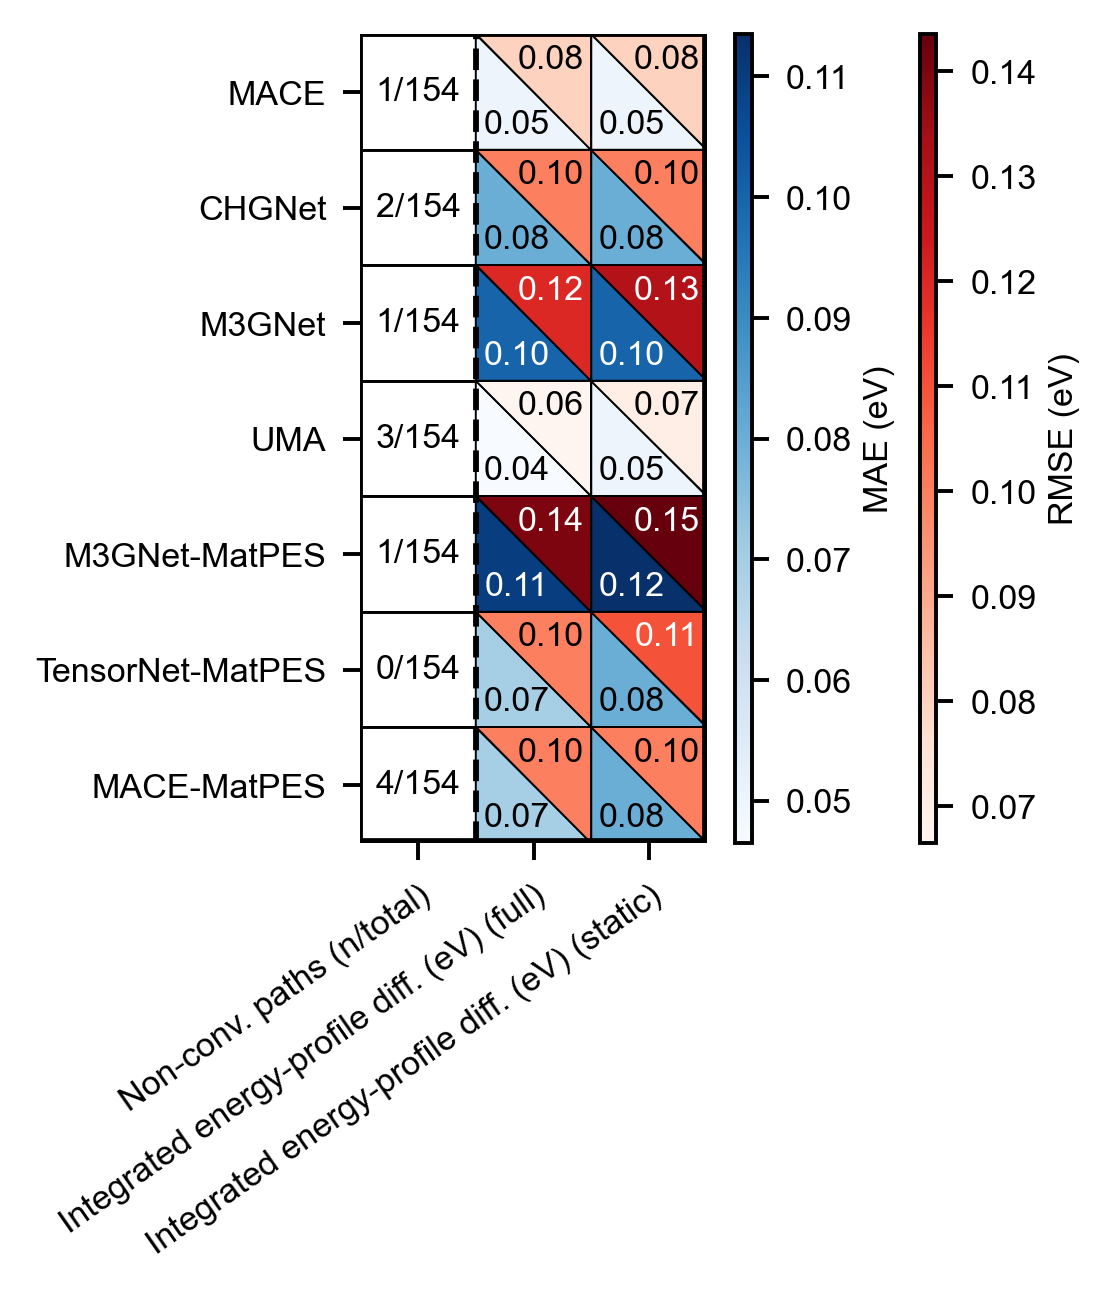

,Non-conv. paths (n/total),Area (full) (MAE/RMSE),Area (static) (MAE/RMSE)
FP,,,
MACE-MP0_medium,1/154,0.05 / 0.08,0.05 / 0.08
CHGNET,2/154,0.08 / 0.10,0.08 / 0.10
M3GNET_pes,1/154,0.10 / 0.12,0.10 / 0.13
UMA_s1_p1,3/154,0.04 / 0.06,0.05 / 0.07
M3GNET_matpes_PBE,1/154,0.11 / 0.14,0.12 / 0.15
TensorNET_matpes_PBE,0/154,0.07 / 0.10,0.08 / 0.11
MACE_matpes_pbe,4/154,0.07 / 0.10,0.08 / 0.10


In [31]:
df_full_idx = full_fp_neb_profile_summary_df.set_index("FP")
df_static_idx = fp_static_on_dft_neb_profile_summary_df.set_index("FP")
df_area_4col = pd.DataFrame({
    "Area (full) (MAE/RMSE)": combine_two(df_full_idx, "MAE Area (eV)", "RMSE Area (eV)"),
    "Area (static) (MAE/RMSE)": combine_two(df_static_idx, "MAE Area (eV)", "RMSE Area (eV)"),
})
area_frac_labels = []
for fp_key in df_area_4col.dropna().index:
    s = full_fp_neb_convergence_summary.get(fp_key, {}).get(PROTOCOL_FULL_FP_NEB, {})
    area_frac_labels.append(f"{s.get('n_neb_not_conv', 0)}/{s.get('n_total', 0)}" if s.get("n_total") else "—")
plot_3col_triangular(
    df_area_4col.dropna(), title=None, text_size=7, figsize=(8.0, 3.0), dpi=350,
    cbar_w=0.006, cbar_gap=0.06, cbar_offset=0.01, cbar_mae_labelpad=2.5, cbar_rmse_labelpad=2.5,
    title_pad=15, xtick_pad=4,
    col_labels=["Non-conv. paths (n/total)", "Integrated energy-profile diff. (eV) (full)",
                "Integrated energy-profile diff. (eV) (static)"],
    rect_cols_pre=[area_frac_labels], save_path=str(FIGURES_DIR / "section10_area_error_heatmap.svg"),
)
area_error_table = pd.DataFrame({"Non-conv. paths (n/total)": area_frac_labels}, index=df_area_4col.dropna().index).join(df_area_4col.dropna())
display(area_error_table)


## 11. Force errors on the DFT-NEB path

### Representative static-path force-error plot

`dft_neb_path_force_errors_df` (protocol `fp_static_on_dft_neb`) covers
all 154 active common paths, subject to per-FP source coverage (Section 2.5).
This plot is a Supporting Information analysis.


  [MACE-MP0_medium | ICSD=143438 path=16]  dft_idx=18  full_idx=24  static_idx=24  barriers=['full', 'static']
  [MACE-MP0_medium | ICSD=8117 path=2]  dft_idx=148  full_idx=33  static_idx=33  barriers=['full', 'static']


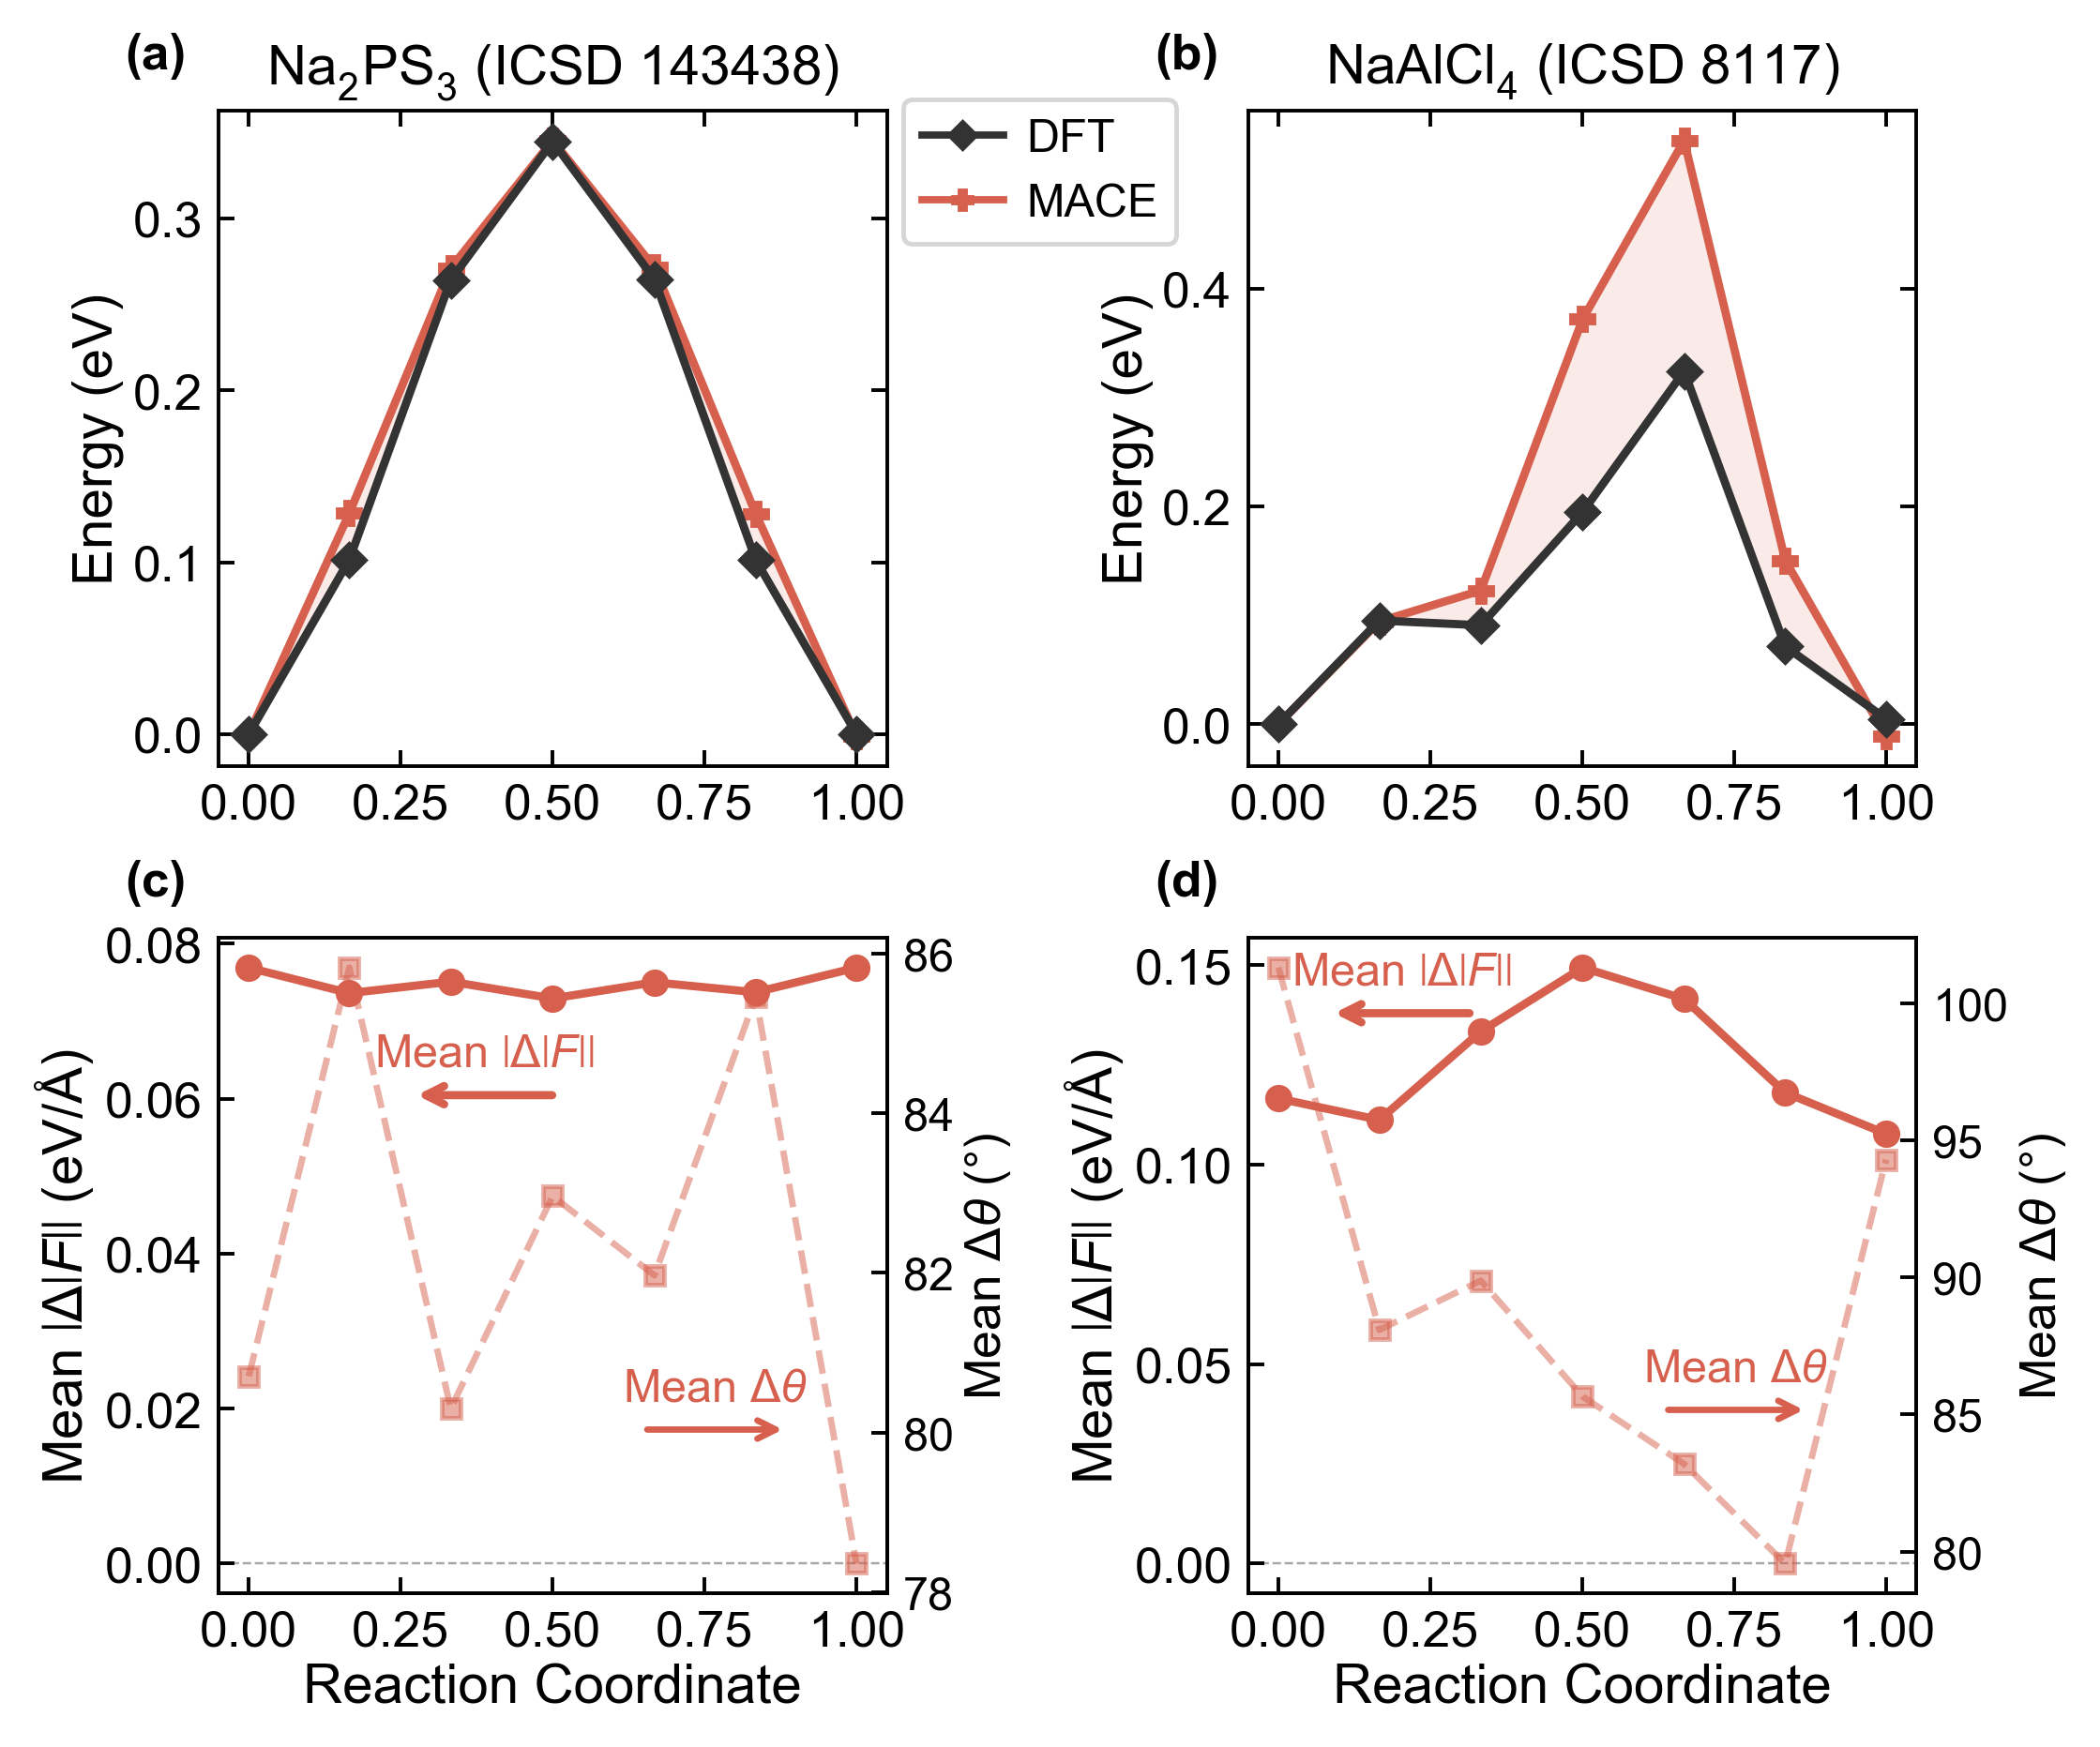

(<Figure size 2275x2100 with 6 Axes>,
 array([[<Axes: title={'center': 'Na$_{2}$PS$_{3}$ (ICSD 143438)'}, ylabel='Energy (eV)'>,
         <Axes: title={'center': 'NaAlCl$_{4}$ (ICSD 8117)'}, ylabel='Energy (eV)'>],
        [<Axes: xlabel='Reaction Coordinate', ylabel='Mean $\\left|\\Delta\\left|F\\right|\\right|$ (eV/Å)'>,
         <Axes: xlabel='Reaction Coordinate', ylabel='Mean $\\left|\\Delta\\left|F\\right|\\right|$ (eV/Å)'>]],
       dtype=object))

In [32]:
plot_two_path_force_error_static(
    sel_mlip="MACE-MP0_medium",
    selected_paths=[('143438', '16'), ('8117', '2')],
    model_names=FP_DISPLAY_NAMES,
    df_ICSD=material_metadata_df,
    df_dft_valid=dft_valid_path_metrics_df,
    df_classification_common=fp_path_metrics_by_short_mode,
    dft_index_lookup=dft_image_position_by_path,
    mlip_index_lookup=fp_image_position_by_fp_protocol_path,
    neb_paths_dft=dft_neb_images_by_position,
    neb_structures_all_mlip=neb_images_position_by_protocol,
    endpoint_rmsd_data=endpoint_rmsd_by_short_mode,
    dft_neb_path_force_errors=dft_neb_path_force_errors_df,
)

### Force-error statistics grouped by static barrier error

> SI Table 5. Force errors on the DFT-NEB path, grouped by static
> barrier error. For each image, the force error is averaged over all
> atoms; reported values are the mean and maximum across all images in
> each group.


In [33]:
# SI-Table-5-specific threshold configuration, distinct from the 0.05 eV
# "good" threshold used in the private 0.05 eV static-case diagnostic
# (neb_diagnostics_private.ipynb) -- these remain two separate, independently
# retained diagnostics per spec section 18, not an inconsistency to resolve.
SI_TABLE5_GOOD_BARRIER_THRESHOLD_EV = 0.01
SI_TABLE5_BAD_BARRIER_THRESHOLD_EV = 0.10

si5_barrier_cases_df = build_static_barrier_case_membership(
    fp_path_metrics_by_protocol, dft_path_metrics_df, dft_valid_path_metrics_df,
    benchmark_pathways_df, FP_ORDER,
    good_threshold_ev=SI_TABLE5_GOOD_BARRIER_THRESHOLD_EV,
    bad_threshold_ev=SI_TABLE5_BAD_BARRIER_THRESHOLD_EV,
)
# "Moderate" (neither good nor poor) is computed by build_static_barrier_case_membership
# but is not one of the two SI Table 5 groups, so it is not displayed here.

dft_neb_legacy_for_si5 = dft_neb_path_force_errors_df.rename(
    columns={"fp_key": "FP", "icsd_id": "ICSD", "source_path_id": "Path"})
dft_neb_legacy_for_si5["ICSD"] = dft_neb_legacy_for_si5["ICSD"].astype(int)
dft_neb_legacy_for_si5["Path"] = dft_neb_legacy_for_si5["Path"].astype(int)

si5_col_labels = {
    "A (good)": f"Both Fwd/Bwd barrier errors < {SI_TABLE5_GOOD_BARRIER_THRESHOLD_EV} eV",
    "B (poor)": f"Either Fwd/Bwd barrier error > {SI_TABLE5_BAD_BARRIER_THRESHOLD_EV} eV",
}
row_labels_si5 = [
    "Mean/max |Δ|F|| over all images (eV/Å)",
    "Mean/max Δθ over all images (°)",
]
row_metrics_si5 = ["mean_abs_delta_force_magnitude", "mean_force_angle_error_deg"]

si5_data = {}
for case_label, col_label in si5_col_labels.items():
    keys = si5_barrier_cases_df[si5_barrier_cases_df["case"] == case_label][["FP", "ICSD", "Path"]]
    merged = keys.merge(dft_neb_legacy_for_si5, on=["FP", "ICSD", "Path"], how="inner")
    for label, metric in zip(row_labels_si5, row_metrics_si5):
        si5_data.setdefault(label, {})[col_label] = (
            f"{merged[metric].mean():.4f} / {merged[metric].max():.4f}" if not merged.empty else "-"
        )

si_table_5 = pd.DataFrame(si5_data).T
display(si_table_5)


,Both Fwd/Bwd barrier errors < 0.01 eV,Either Fwd/Bwd barrier error > 0.1 eV
Mean/max |Δ|F|| over all images (eV/Å),0.0733 / 0.3373,0.1177 / 0.5098
Mean/max Δθ over all images (°),82.8296 / 125.1694,86.2948 / 126.3156


## 12. Non-converged full FP-NEB pathway example

`NONCONVERGED_EXAMPLE_FP`/`NONCONVERGED_EXAMPLE_ICSD`/`NONCONVERGED_EXAMPLE_PATH`
selects a specific non-converged full FP-NEB pathway (its climbing-image
NEB run did not meet the 0.05 eV/Å convergence threshold within 1000
steps, Section 0.3) to compare the DFT-NEB reference, the full FP-NEB
workflow, and static FP evaluations on the DFT-NEB images side by side.


M3GNET_pes ICSD 157654 Path 13: neb_converged=False, neb_last_fmax=0.846325, neb_n_steps=1001

Li7P3S11 | M3GNET_pes | ICSD=157654 | Path=13
ICSD 157654  —  Path 13


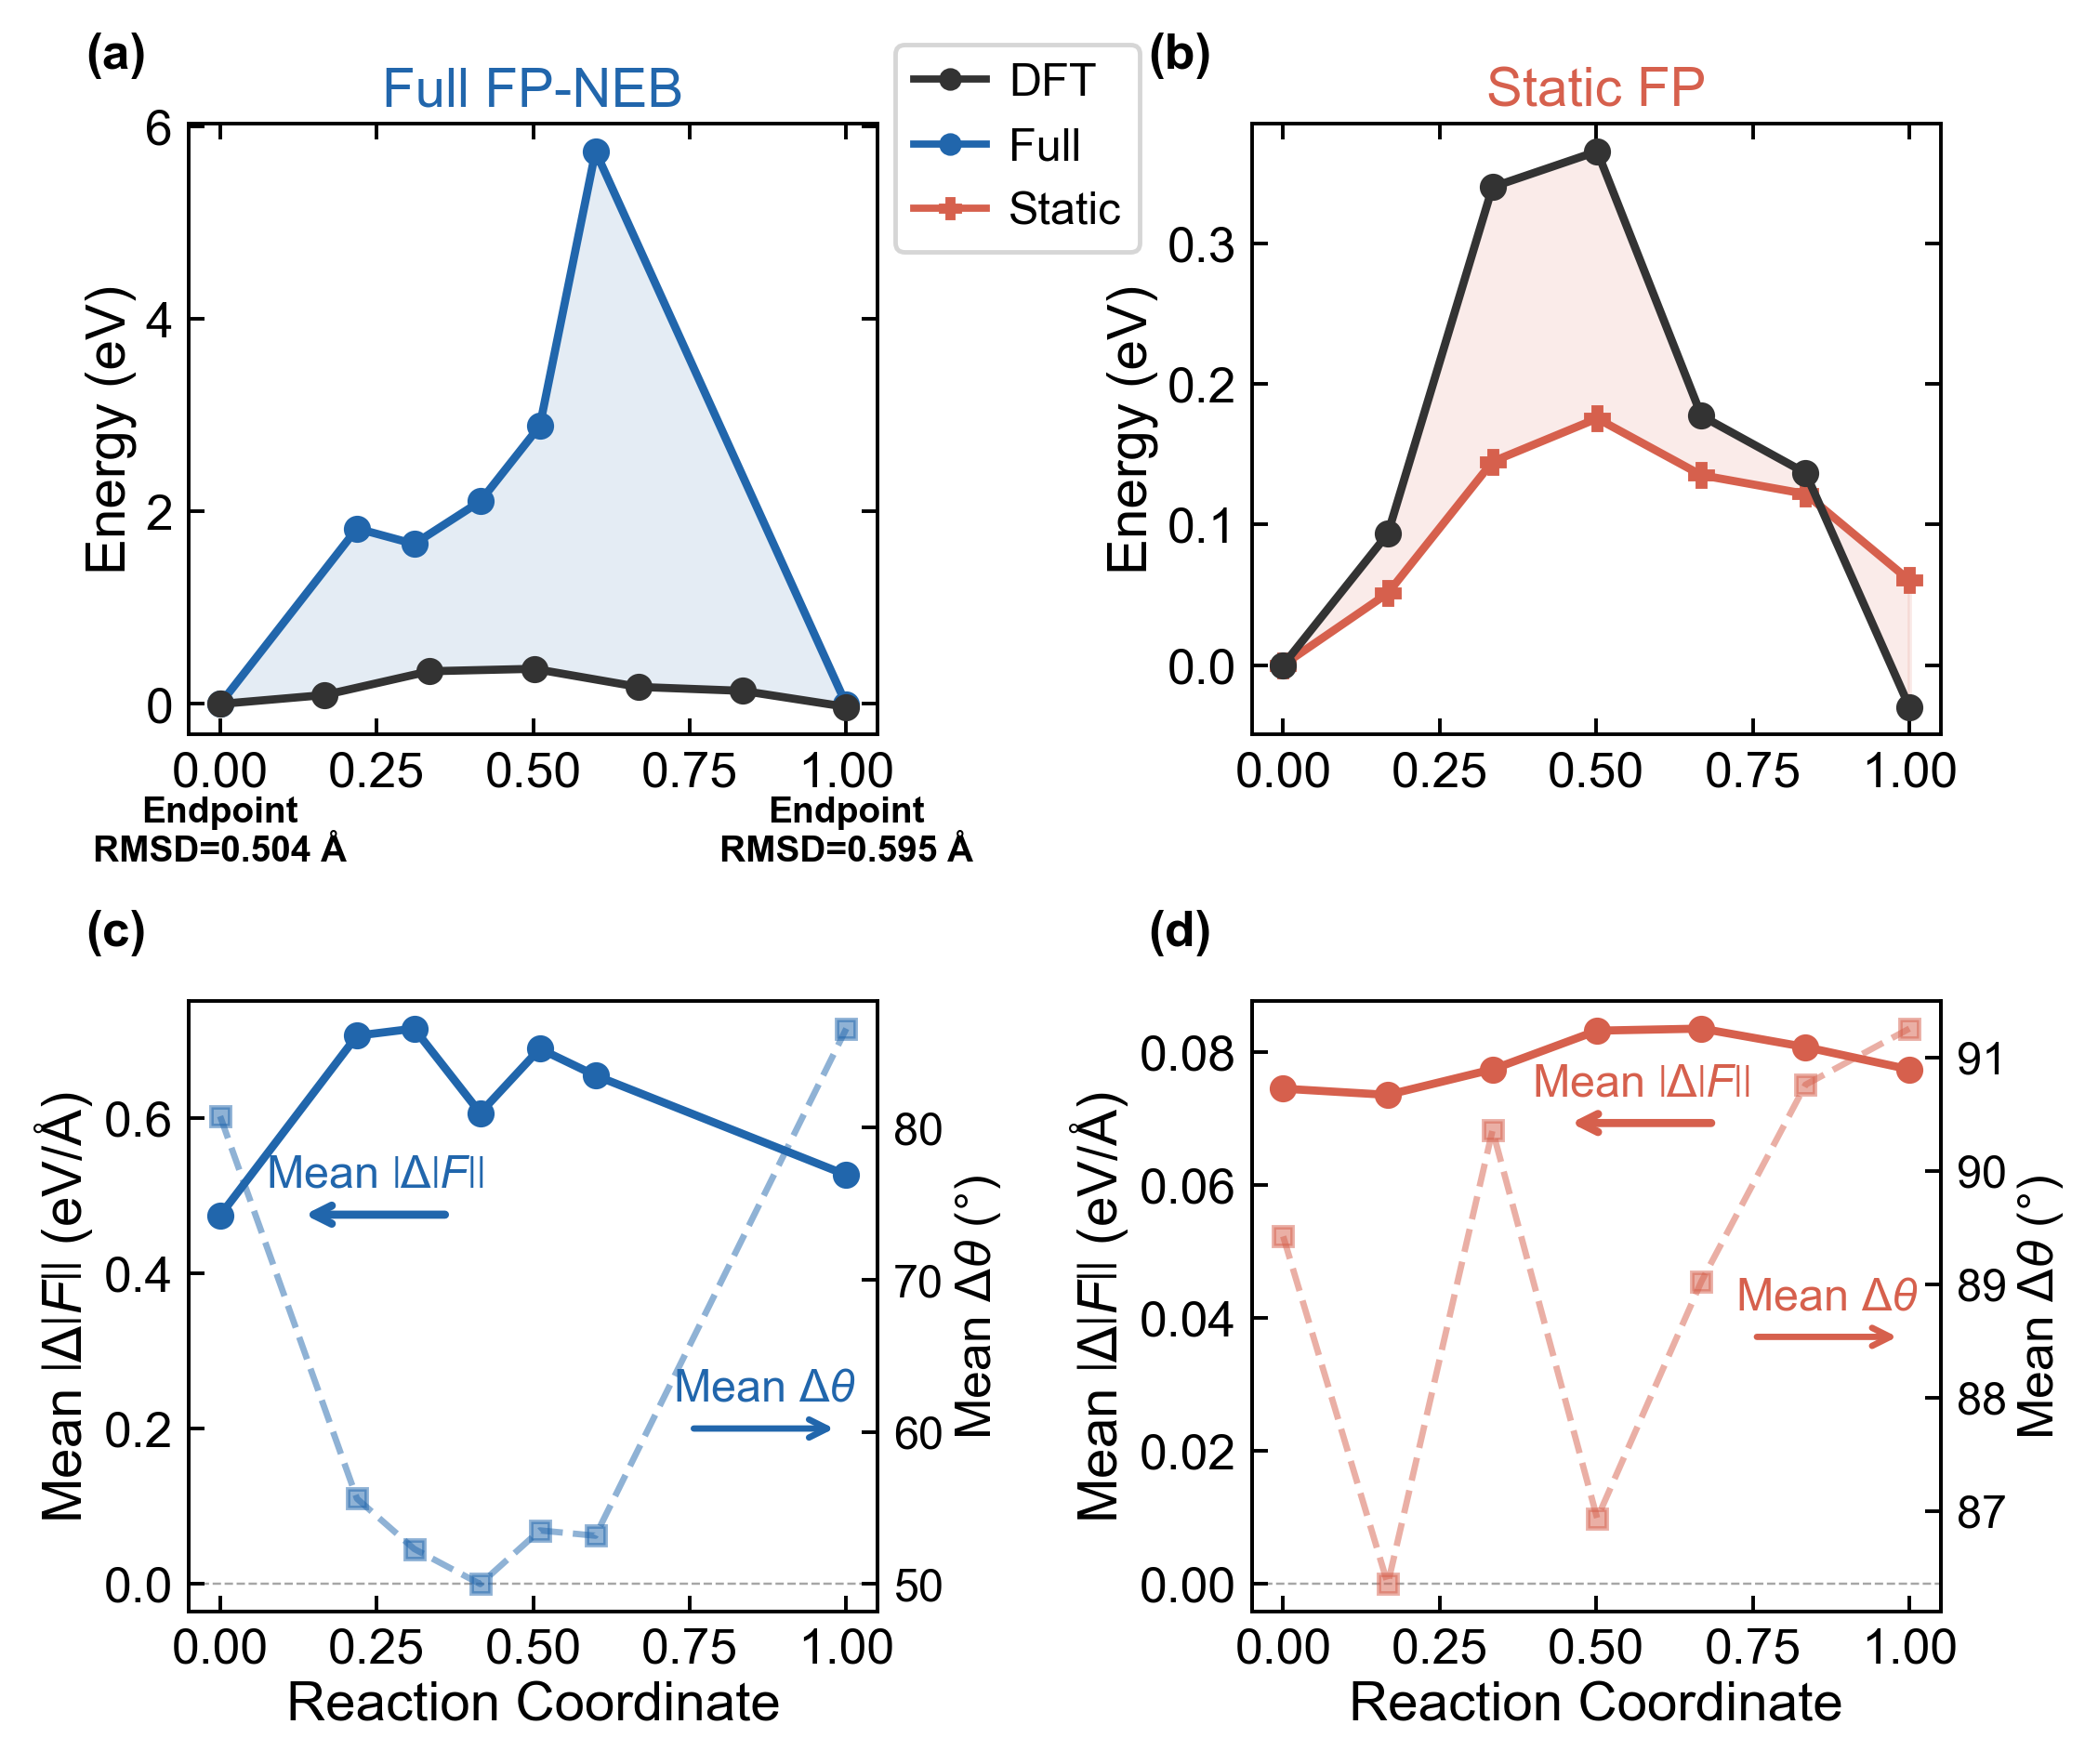

(<Figure size 2275x2100 with 6 Axes>,
 array([[<Axes: title={'center': 'Full FP-NEB'}, ylabel='Energy (eV)'>,
         <Axes: title={'center': 'Static FP'}, ylabel='Energy (eV)'>],
        [<Axes: xlabel='Reaction Coordinate', ylabel='Mean $\\left|\\Delta\\left|F\\right|\\right|$ (eV/Å)'>,
         <Axes: xlabel='Reaction Coordinate', ylabel='Mean $\\left|\\Delta\\left|F\\right|\\right|$ (eV/Å)'>]],
       dtype=object))

In [34]:
NONCONVERGED_EXAMPLE_FP = "M3GNET_pes"
NONCONVERGED_EXAMPLE_ICSD = "157654"
NONCONVERGED_EXAMPLE_PATH = "13"

_status = full_fp_neb_status_by_fp_path.get(NONCONVERGED_EXAMPLE_FP, {}).get(
    (NONCONVERGED_EXAMPLE_ICSD, NONCONVERGED_EXAMPLE_PATH), {})
print(f"{NONCONVERGED_EXAMPLE_FP} ICSD {NONCONVERGED_EXAMPLE_ICSD} Path {NONCONVERGED_EXAMPLE_PATH}: "
      f"neb_converged={_status.get('neb_converged')}, "
      f"neb_last_fmax={_status.get('neb_last_fmax')}, "
      f"neb_n_steps={_status.get('neb_n_steps')}")

plot_single_path_dft_full_static(
    sel_mlip=NONCONVERGED_EXAMPLE_FP,
    sel_icsd=NONCONVERGED_EXAMPLE_ICSD,
    sel_path_id=NONCONVERGED_EXAMPLE_PATH,
    df_ICSD=material_metadata_df,
    df_dft_valid=dft_valid_path_metrics_df,
    df_classification_common=fp_path_metrics_by_short_mode,
    mlip_index_lookup=fp_image_position_by_fp_protocol_path,
    dft_index_lookup=dft_image_position_by_path,
    endpoint_rmsd_data=endpoint_rmsd_by_short_mode,
    neb_paths_dft=dft_neb_images_by_position,
    neb_structures_all_mlip=neb_images_position_by_protocol,
    full_fp_neb_path_force_errors=full_fp_neb_path_force_errors_df,
    dft_neb_path_force_errors=dft_neb_path_force_errors_df,
)
